# Sobek Stone House Cappadocia - Guest Review Analysis (2020-2026)

**Goal:** understand what guests say about the hotel across five booking platforms, how this changed over the years, whether star ratings match the written comments, and which themes (breakfast, cleanliness, view, staff, etc.) drive satisfaction, so I can make evidence-based recommendations.

**Data sources** (scraped with Apify, September 2026):

| Source | Rating scale | Notes |
|---|---|---|
| Google Maps | 1-5 | Includes Google's own English translations |
| Tripadvisor | 1-5 | Has review titles and sub-ratings |
| Booking.com | 1-10 | Reviews split into *liked* / *disliked* text |
| Expedia (incl. Hotels.com) | 1-10 | Has sub-ratings (cleanliness, service…) |
| Trip.com | 1-10 | Partly translated |

**Notebook structure**
1. Setup
2. Loading the raw data
3. Standardising the sources into one table
4. Translating non-English reviews
5. Final dataset check & save
6. Exploratory data analysis
7. Sentiment analysis & rating–text match
8. Topic analysis: what guests talk about and complain about
9. Findings & recommendations
10. Limitations

## Executive Summary

**What I did:** I collected **966 guest reviews** of Sobek Stone House Cappadocia from Google, Tripadvisor, Expedia, Booking.com and Trip.com (2020-2026). After removing duplicates, I analysed **919 unique reviews**. I translated non-English reviews, measured the sentiment of every review and sentence with a pre-trained RoBERTa model, and used a keyword dictionary to find what guests talk about and complain about.

**Key findings**
- **Guests are very satisfied overall (4.62 / 5), but ratings have dropped significantly**, from **4.84 in 2020-2022 to 4.45 in 2023-2026**, and negative reviews rose from about 0-2% to about 10%. Star ratings and review texts tell the same story.
- **The hotel's strengths are stable**: the **balloon view** and **location** are almost never criticised, and **staff** and **cleanliness** are praised in more than 80% of mentions.
- **The drop is driven by pricing and payment practices.** Value & price became the most negative topic (negative mentions **12% → 45%**), mainly because of **hidden or extra charges** (paid water, sauna and spa fees, a 10% service charge) and **being asked to pay in euros or GBP or in cash**. Reviews with a price complaint average only **2.38 stars**.
- **Rooms, pool and food have also worsened**: bathroom smells, small beds and rooms not matching the booking; a poorly maintained pool that is often unusable outside summer; and a limited menu with no cook at times.
- **Staff problems are rare but costly**: a staff complaint lowers the rating by **2.3 stars** on average, and foreign guests complain about staff twice as often as Turkish guests.
- **The hotel has almost stopped replying to reviews** (from **97% in 2021 to 8% in 2026**), and it has never replied on Booking.com.

**Top recommendations**
1. **Make pricing transparent**: show all costs upfront, include water in the room price, charge in Turkish lira by default and accept card payments.
2. **Improve room upkeep**: check bathrooms and fittings before each arrival, and give guests the room and view they booked.
3. **Train staff** in communication, complaint handling and basic English, and keep enough staff in the low season.
4. **Maintain the pool daily** and clearly communicate which pools are open, especially in spring and winter.
5. **Reply to every review**, starting with the negative ones and on all platforms.
6. **Promote the strengths** (balloon view, location, hospitality) in all marketing.

**Main limitations:** small samples on Booking and Trip.com, 2026 only covers reviews up to September, offline translations are rougher than commercial ones, and topics are based on keyword lists, so the results show associations rather than proven causes (see Section 10).

## 1. Setup

### 1.1 Install libraries (run once, then restart the kernel)

In [1]:
# remove the # and run once if the libraries are not installed
##%pip install pandas numpy matplotlib seaborn transformers sentencepiece sacremoses torch

### 1.2 Import libraries and notebook settings

In [2]:
import os
import glob
import time
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from scipy.stats import mannwhitneyu


# Display settings: show long review texts and all columns
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Folder where all the Apify CSV exports are stored
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

## 2. Loading the Raw Data

### 2.1 Locate the files
Each Apify export has a long, dated file name. Instead of typing the exact names, I search the `data` folder for a keyword per platform, so the notebook still works if you re-scrape later.

In [3]:
# Keyword(s) that identify each platform's file name
FILE_KEYWORDS = {
    "Google": ["google"],
    "Booking": ["booking"],
    "Expedia": ["expedia"],
    "Tripadvisor": ["tripadvisor"],
    "Trip.com": ["trip-com", "tripcom"],
}

def find_file(keywords):
    """Return the newest CSV in DATA_DIR whose name contains one of the keywords."""
    matches = [
        f for f in glob.glob(os.path.join(DATA_DIR, "*.csv"))
        if any(k in os.path.basename(f).lower() for k in keywords)
    ]
    return max(matches, key=os.path.getmtime) if matches else None

files = {source: find_file(keys) for source, keys in FILE_KEYWORDS.items()}
files

{'Google': 'data/dataset_Google-Maps-Reviews-Scraper_2026-09-26_21-42-35-304.csv',
 'Booking': 'data/dataset_booking-reviews-scraper_2026-09-26_21-58-16-507.csv',
 'Expedia': 'data/dataset_expedia-hotel-reviews-scraper_2026-09-26_22-03-00-143.csv',
 'Tripadvisor': 'data/dataset_tripadvisor-reviews_2026-09-26_22-04-50-360.csv',
 'Trip.com': 'data/dataset_trip-com-reviews-scraper_2026-09-26_22-07-18-007.csv'}

### 2.2 Load each file and take a first look

In [4]:
raw = {source: pd.read_csv(path) for source, path in files.items() if path}

for source, data in raw.items():
    print(f"{source:<12} {data.shape[0]:>4} rows, {data.shape[1]:>3} columns")

Google        568 rows,  97 columns
Booking        44 rows,  50 columns
Expedia       183 rows,  51 columns
Tripadvisor   142 rows,  67 columns
Trip.com       61 rows,  40 columns


## 3. Standardising the Sources into One Table
Every platform uses different column names, rating scales and category labels. I convert each one into the **same set of columns** so they can be combined:

| Column | Meaning |
|---|---|
| `source` | Platform name |
| `review_date`, `year` | When the review was posted |
| `rating_raw`, `rating_scale` | Original score and its maximum (5 or 10) |
| `rating_5` | Score converted to a common 1-5 scale |
| `title` | Review title (where the platform has one) |
| `text_original` / `text_en` | Review text in its original language / in English |
| `liked_*`, `disliked_*` | Booking.com only: positive and negative parts |
| `language` | Original language code |
| `travel_group` | Family, Couple, Friends, Solo, Business or Other |
| `owner_reply`, `has_reply` | Hotel's response |
| `sub_*` | Sub-ratings (cleanliness, service, rooms…) on a 1-5 scale |

### 3.1 Helper functions

In [5]:
def map_travel_group(value):
    """Map each platform's traveller label to one shared category."""
    if pd.isna(value):
        return "Unknown"
    v = str(value).lower()
    if "famil" in v:
        return "Family"
    if "coupl" in v or "partner" in v:
        return "Couple"
    if "friend" in v or "group" in v:
        return "Friends"
    if "solo" in v:
        return "Solo"
    if "business" in v:
        return "Business"
    return "Other"


# Sub-rating names differ per platform, so I map them to shared column names
SUB_RATING_NAMES = {
    "cleanliness": "sub_cleanliness",
    "service": "sub_service",
    "rooms": "sub_rooms",
    "room comfort": "sub_rooms",
    "location": "sub_location",
    "value": "sub_value",
    "hotel condition": "sub_condition",
    "amenities": "sub_amenities",
    "sleep quality": "sub_sleep",
}


def clean_text(series):
    """Strip whitespace and turn empty strings into missing values."""
    s = series.astype("string").str.strip()
    return s.mask(s == "")

### 3.2 Google
Google already provides English translations (`textTranslated`). I keep only reviews posted on Google itself, because the few Tripadvisor/Trip.com reviews Google shows are just a sample, and I scrape those platforms directly.

In [6]:
g = raw["Google"]
g = g[g["reviewOrigin"] == "Google"].copy()

google = pd.DataFrame({
    "source": "Google",
    "review_id": g["reviewId"],
    "review_date": g["publishedAtDate"],
    "rating_raw": g["stars"],
    "rating_scale": 5,
    "title": pd.NA,
    "text_original": clean_text(g["text"]),
    "language": g["originalLanguage"],
    "travel_group": g["reviewContext/Travel group"].map(map_travel_group),
    "owner_reply": clean_text(g["responseFromOwnerText"]),
    # Google sub-ratings are already on a 1-5 scale
    "sub_rooms": g["reviewDetailedRating/Rooms"],
    "sub_service": g["reviewDetailedRating/Service"],
    "sub_location": g["reviewDetailedRating/Location"],
})

# English text: Google's translation if available, otherwise the original (already English)
google["text_en"] = clean_text(g["textTranslated"]).fillna(
    google["text_original"].where(google["language"] == "en")
)
print(len(google), "Google reviews")

536 Google reviews


### 3.3 Booking.com
Booking splits each review into what the guest **liked** and **disliked**. I keep both parts separately (useful later as ready-labelled positive/negative text) and also join them into one `text_original`.

In [7]:
b = raw["Booking"].copy()

booking = pd.DataFrame({
    "source": "Booking",
    "review_id": b["id"].astype(str),
    "review_date": b["reviewDate"],
    "rating_raw": b["rating"],
    "rating_scale": 10,
    "title": clean_text(b["reviewTitle"]),
    "liked_original": clean_text(b["likedText"]),
    "disliked_original": clean_text(b["dislikedText"]),
    "language": b["reviewLanguage"],
    "travel_group": b["travelerType"].map(map_travel_group),
    "owner_reply": clean_text(b["propertyResponse"]),
})

# Join liked + disliked into one text (empty parts are skipped)
booking["text_original"] = clean_text(
    booking[["liked_original", "disliked_original"]]
    .apply(lambda r: " ".join(x for x in r if pd.notna(x)), axis=1)
)
print(len(booking), "Booking reviews")

44 Booking reviews


### 3.4 Expedia (incl. Hotels.com)
   Expedia and Hotels.com belong to the same company and share one review pool. Of the 183 reviews, 147 were written on Hotels.com, 35 on Expedia and 1 on Orbitz, so Hotels.com is already fully covered and I did not scrape it separately.
   Expedia stores sub-ratings as text such as `"Cleanliness: 10"`, so I split each one into a name and a score and convert it to the 1-5 scale.

In [8]:
e = raw["Expedia"].copy()

expedia = pd.DataFrame({
    "source": "Expedia",
    "brand": e["brandType"],
    "review_id": e["reviewId"].astype(str),
    "review_date": e["submittedAt"],
    "rating_raw": e["overallRating"],
    "rating_scale": 10,
    "title": pd.NA,
    "text_original": clean_text(e["reviewText"]),
    "language": e["language"],
    "travel_group": e["travelerCategories/0"].map(map_travel_group),
    "owner_reply": clean_text(e["ownerResponse/text"]),
})

# Parse "Cleanliness: 10" -> sub_cleanliness = 5.0
for col in [c for c in e.columns if c.startswith("subRatings/")]:
    parts = e[col].str.split(":", n=1, expand=True)
    if parts.shape[1] < 2:
        continue
    names = parts[0].str.strip().str.lower().map(SUB_RATING_NAMES)
    scores = pd.to_numeric(parts[1], errors="coerce") / 2
    for sub_name in names.dropna().unique():
        mask = names == sub_name
        expedia.loc[mask, sub_name] = scores[mask]

print(len(expedia), "Expedia reviews")

183 Expedia reviews


### 3.5 Tripadvisor
Tripadvisor sub-ratings come as name/value pairs (`subratings/0/name`, `subratings/0/value`, …) on a 1-5 scale.

In [9]:
t = raw["Tripadvisor"].copy()

tripadvisor = pd.DataFrame({
    "source": "Tripadvisor",
    "review_id": t["id"].astype(str),
    "review_date": t["publishedDate"],
    "rating_raw": t["rating"],
    "rating_scale": 5,
    "title": clean_text(t["title"]),
    "text_original": clean_text(t["text"]),
    "language": t["lang"],          # language the text is actually written in
    "travel_group": t["tripType"].map(map_travel_group),
    "owner_reply": clean_text(t["ownerResponse/text"]),
})

# Turn each name/value pair into its own sub_* column
i = 0
while f"subratings/{i}/name" in t.columns:
    names = t[f"subratings/{i}/name"].str.lower().map(SUB_RATING_NAMES)
    values = pd.to_numeric(t[f"subratings/{i}/value"], errors="coerce")
    for sub_name in names.dropna().unique():
        mask = names == sub_name
        tripadvisor.loc[mask, sub_name] = values[mask]
    i += 1

print(len(tripadvisor), "Tripadvisor reviews")

142 Tripadvisor reviews


### 3.6 Trip.com
Trip.com translated some reviews itself (`translatedContent`); I reuse those and translate the rest in Section 4.

In [10]:
c = raw["Trip.com"].copy()

tripcom = pd.DataFrame({
    "source": "Trip.com",
    "review_id": c["id"].astype(str),
    "review_date": c["createDate"],
    "rating_raw": c["rating"],
    "rating_scale": 10,
    "title": pd.NA,
    "text_original": clean_text(c["content"]),
    "language": c["language"],
    "travel_group": c["travelTypeText"].map(map_travel_group),
    "owner_reply": clean_text(c["feedbackContent"]),
})

tripcom["text_en"] = clean_text(c["translatedContent"]).fillna(
    tripcom["text_original"].where(tripcom["language"] == "en")
)
print(len(tripcom), "Trip.com reviews")

61 Trip.com reviews


### 3.7 Combine all sources

In [11]:
reviews = pd.concat([google, booking, expedia, tripadvisor, tripcom], ignore_index=True)

# Dates -> one common datetime format, then extract the year
reviews["review_date"] = pd.to_datetime(reviews["review_date"], utc=True, errors="coerce", format="mixed")
reviews["year"] = reviews["review_date"].dt.year

# Common 1-5 rating scale (10-point scores are divided by 2)
reviews["rating_raw"] = pd.to_numeric(reviews["rating_raw"], errors="coerce")
reviews["rating_5"] = reviews["rating_raw"] / (reviews["rating_scale"] / 5)

# Flags used throughout the analysis
reviews["has_text"] = reviews["text_original"].notna()
reviews["has_reply"] = reviews["owner_reply"].notna()

# English text for English reviews that don't have it yet
is_en = reviews["language"].eq("en")
reviews["text_en"] = reviews["text_en"].fillna(reviews["text_original"].where(is_en))
reviews["liked_en"] = reviews["liked_original"].where(is_en)
reviews["disliked_en"] = reviews["disliked_original"].where(is_en)

print(reviews.shape)
reviews["source"].value_counts()

(966, 28)


source
Google         536
Expedia        183
Tripadvisor    142
Trip.com        61
Booking         44
Name: count, dtype: int64

### 3.8 Flag duplicate reviews across platforms
Some reviews appear on more than one site: Trip.com shows many Expedia reviews, and some guests post the same text on Google and Tripadvisor. I first **flag** these (`is_duplicate`), check them side by side, and then remove them in 3.9.

The copy on the platform higher in `SOURCE_PRIORITY` is kept as the original. Very short texts (e.g. "Excellent") are ignored, because different guests can write the same word.

In [12]:
SOURCE_PRIORITY = ["Google", "Tripadvisor", "Expedia", "Booking", "Trip.com"]

# Comparison key: lowercase letters/digits only, first 120 characters
text_key = (
    reviews["text_original"].str.lower()
    .str.replace(r"\W", "", regex=True)
    .str[:120]
)
text_key = text_key.where(text_key.str.len() >= 30)   # skip very short texts

# Sort by platform priority so the first copy kept is the "original"
order = reviews["source"].map({s: i for i, s in enumerate(SOURCE_PRIORITY)})
reviews["is_duplicate"] = False
reviews.loc[order.sort_values().index, "is_duplicate"] = (
    text_key.loc[order.sort_values().index].duplicated() & text_key.notna()
)

print("Duplicates flagged:", reviews["is_duplicate"].sum())
reviews[reviews["is_duplicate"]].groupby("source").size()

Duplicates flagged: 47


source
Booking         2
Expedia         2
Google          2
Trip.com       33
Tripadvisor     8
dtype: int64

In [13]:
# Show duplicate pairs side by side to check they are really the same review
key = reviews["text_original"].str.lower().str.replace(r"\W", "", regex=True).str[:120]
dups = reviews[key.duplicated(keep=False) & key.str.len().ge(30)].assign(key=key)
dups.sort_values(["key", "source"])[["source", "review_date", "rating_5", "text_original"]].head(20)

,source,review_date,rating_5,text_original
615,Expedia,2025-08-14 23:12:55+00:00,4.0,Belle vue et personnel très attentionné. Mais 1er hôtel de ma vie à facturer la parte d’une carte. Pas très sympa et donc assez dommage.
946,Trip.com,2025-08-15 07:12:55+00:00,4.0,Belle vue et personnel très attentionné. Mais 1er hôtel de ma vie à facturer la parte d’une carte. Pas très sympa et donc assez dommage.
660,Expedia,2024-07-07 11:50:58+00:00,5.0,"Dekorasyon, tasarım, çok güzeldi, yatak rahattı, kahvaltı kötü desem hak yemiş olmam. İyi değildi. Keşke kahvaltı da mükemmel olsaydı, o zaman kesin bir daha giderdim diyebilirim."
960,Trip.com,2024-07-07 19:50:58+00:00,5.0,"Dekorasyon, tasarım, çok güzeldi, yatak rahattı, kahvaltı kötü desem hak yemiş olmam. İyi değildi. Keşke kahvaltı da mükemmel olsaydı, o zaman kesin bir daha giderdim diyebilirim."
695,Expedia,2023-08-24 10:30:37+00:00,4.0,"Design of hotel is very nice, compared to other hotel in cave style. \nThe room is very big and clean, with a little balcony, fridge, teapot but one cup for 2 people, a double bed, sofa and a chai..."
786,Tripadvisor,2023-08-24 00:00:00+00:00,4.0,"Design of hotel is very nice, compared to other hotel in cave style. \nThe room is very big and clean, with a little balcony, fridge, teapot but one cup for 2 people, a double bed, sofa and a chai..."
606,Expedia,2025-10-21 14:10:00+00:00,5.0,Easy location to reach. Onsite parking. Town is a 2 minute drive maybe 10 minte walk. Most activotoes pick you up
916,Trip.com,2025-10-21 22:10:00+00:00,5.0,Easy location to reach. Onsite parking. Town is a 2 minute drive maybe 10 minte walk. Most activotoes pick you up
672,Expedia,2024-06-10 16:06:25+00:00,5.0,For a newer hotel this was one of the best. Can’t beat the view and close to everything you need it to be.
929,Trip.com,2024-06-11 00:06:25+00:00,5.0,For a newer hotel this was one of the best. Can’t beat the view and close to everything you need it to be.


### 3.9 Remove duplicate reviews
The check above confirms that flagged duplicates have the same text, rating and date (Expedia/Trip.com times differ by exactly 8 hours, which is China's time zone). I remove them so that every analysis uses the same set of unique reviews and no opinion is counted twice.

In [14]:
# Remove duplicate reviews so each opinion is counted only once
before = len(reviews)
reviews = reviews[~reviews["is_duplicate"]].reset_index(drop=True)

print(f"Removed {before - len(reviews)} duplicates, {len(reviews)} unique reviews left")
reviews["source"].value_counts()

Removed 47 duplicates, 919 unique reviews left


source
Google         534
Expedia        181
Tripadvisor    134
Booking         42
Trip.com        28
Name: count, dtype: int64

## 4. Translating Non-English Reviews
To analyse every review with the same English sentiment model and topic keywords, I translate the remaining non-English texts.

We first tried Google Translate (`deep-translator`), but Google blocked my requests after too many requests, so I switched to free **offline** Helsinki-NLP models that run on the laptop with no limits.

Translations are saved to `data/translation_cache.csv`, so if you run this section again, already-translated texts are read from the cache instead of being translated again.

### 4.1 Which reviews still need translating?

In [15]:
# (column with original text, column that should hold the English version)
TEXT_PAIRS = [
    ("text_original", "text_en"),
    ("liked_original", "liked_en"),        # Booking only
    ("disliked_original", "disliked_en"),  # Booking only
]

def needs_translation(df, src, dst):
    return df[src].notna() & df[dst].isna()

for src, dst in TEXT_PAIRS:
    todo = needs_translation(reviews, src, dst)
    print(f"{src:<18} {todo.sum():>4} texts to translate")

# Breakdown by source for the main review text
needs_translation(reviews, "text_original", "text_en").groupby(reviews["source"]).sum()

text_original       171 texts to translate
liked_original       15 texts to translate
disliked_original    10 texts to translate


source
Booking        16
Expedia        63
Google          1
Trip.com       12
Tripadvisor    79
dtype: int64

### 4.2 Translate with caching

I use two Helsinki-NLP models: a dedicated **Turkish→English** model (most non-English reviews are Turkish) and a **multilingual→English** model for all other languages. Reviews are split into sentences first, because these models translate short pieces more accurately.

*Note:* offline translations are slightly rougher than Google's (e.g. names and place names are sometimes translated literally), but the overall meaning and tone are kept, which is what the sentiment and topic analysis need.

In [16]:
CACHE_PATH = os.path.join(DATA_DIR, "translation_cache.csv")

# Load previous translations (original text -> English)
if os.path.exists(CACHE_PATH):
    cache = pd.read_csv(CACHE_PATH).set_index("original")["english"].to_dict()
else:
    cache = {}

def load_model(name):
    """Download (first time only) and load a translation model and its tokenizer."""
    tokenizer = AutoTokenizer.from_pretrained(name)
    model = AutoModelForSeq2SeqLM.from_pretrained(name)
    return tokenizer, model

# Two free offline models (~300 MB each):
# a dedicated Turkish model, since most reviews are Turkish, and a multilingual one for the rest
translators = {
    "tr": load_model("Helsinki-NLP/opus-mt-tr-en"),
    "other": load_model("Helsinki-NLP/opus-mt-mul-en"),
}

def save_cache():
    pd.DataFrame({"original": list(cache.keys()), "english": list(cache.values())}) \
        .to_csv(CACHE_PATH, index=False, encoding="utf-8-sig")

def split_sentences(text):
    """Split into sentences: the models translate short pieces more accurately."""
    parts = re.split(r"(?<=[.!?])\s+|(?<=[。！？])|\n+", text)
    return [p.strip() for p in parts if p.strip()]

def translate(text, lang):
    """Translate one review to English, using the cache when possible."""
    if text in cache:
        return cache[text]
    tokenizer, model = translators["tr"] if lang == "tr" else translators["other"]
    sentences = split_sentences(text) or [text]
    batch = tokenizer(sentences, return_tensors="pt", padding=True, truncation=True, max_length=512)
    output = model.generate(**batch, num_beams=4, no_repeat_ngram_size=3)
    english = " ".join(tokenizer.batch_decode(output, skip_special_tokens=True))
    cache[text] = english
    return english

for src, dst in TEXT_PAIRS:
    todo = reviews.index[needs_translation(reviews, src, dst)]
    for n, idx in enumerate(todo, start=1):
        reviews.at[idx, dst] = translate(reviews.at[idx, src], reviews.at[idx, "language"])
        if n % 25 == 0:
            save_cache()
            print(f"{src}: {n}/{len(todo)} done")

def save_cache():
    """Save translations to CSV (never overwrite the file with an empty cache)."""
    if not cache:
        return
    pd.DataFrame({"original": list(cache.keys()), "english": list(cache.values())}) \
        .to_csv(CACHE_PATH, index=False, encoding="utf-8-sig")

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

text_original: 25/171 done
text_original: 50/171 done
text_original: 75/171 done
text_original: 100/171 done
text_original: 125/171 done
text_original: 150/171 done


### 4.3 Check translation coverage
Every review that has text should now also have English text. Booking's combined `text_en` is rebuilt from the translated liked/disliked parts.

In [17]:
# Rebuild Booking's combined English text from the translated parts
is_booking = reviews["source"].eq("Booking")
reviews.loc[is_booking, "text_en"] = clean_text(
    reviews.loc[is_booking, ["liked_en", "disliked_en"]]
    .apply(lambda r: " ".join(x for x in r if pd.notna(x)), axis=1)
)

coverage = reviews[reviews["has_text"]].groupby("source").agg(
    with_text=("has_text", "sum"),
    with_english=("text_en", lambda s: s.notna().sum()),
)
coverage["missing"] = coverage["with_text"] - coverage["with_english"]
coverage

,with_text,with_english,missing
source,,,
Booking,25,25,0
Expedia,113,113,0
Google,441,441,0
Trip.com,28,28,0
Tripadvisor,134,134,0


In [18]:
# Spot-check a few translations (a good chance to check the Turkish ones yourself!)
sample = reviews[reviews["language"].ne("en") & reviews["text_en"].notna()]
sample[["source", "language", "text_original", "text_en"]].sample(5, random_state=1)

,source,language,text_original,text_en
231,Google,tr,Çalışanlar çok ilgiliydi kaliteli hizmet çok memnun kaldık teşekkürler,"The staff were very attentive, the service was excellent, we were very satisfied, thank you."
453,Google,tr,Çok güzel ve temiz bir otel. Çalışanlar ilgili özellikle resepsiyondan Bilge Hanım her konuda yardımcı oluyor. Balonların muhteşem atmosferini izlemek için harika bir otel. Konumu da Göreme de her...,"A very nice and clean hotel. The staff is attentive, especially Bilge Hanım at the front desk, who is always helpful. It's a great hotel for watching the magnificent balloons. The location is also..."
88,Google,tr,Konaklamak için çok sebep bulabileceğiniz bir otel.\nÖncelikle temizlik ve hijyen açısından bir kusur bulamazsınız. Kahvaltısı efsane lezzetli ve kalitesi yüksek bir açık büfesi vardı ( sadece aşı...,"This is a hotel where you'll find many reasons to stay. First of all, you won't find any fault in terms of cleanliness and hygiene. The breakfast was incredibly delicious and had a high-quality bu..."
480,Google,tr,Kapadokya bölgesinde konaklamak için çok güzel bir otel.Gerek temizlik gerekse mimarisi ve konumu bakımından oldukça güzel.Kahvaltısı ise organik bahçe ürünleriyle sunuluyor ve gayet temiz ve ...,"This is a very nice hotel to stay in the Cappadocia region. It's quite beautiful in terms of cleanliness, architecture, and location. The breakfast is served with organic garden products and is ve..."
190,Google,tr,"Kapadokya bölgesinde kalınacak en iyi otel. Yeri mükemmel , otoparkı çok iyi çok yeterli, çalışanların hepsi çok nazik , ilgili , işlerini mükemmel yapıyorlar. Kahvaltı eksiksiz, yemek salonu ku...","The best hotel to stay at in the Cappadocia region. The location is perfect, the parking is excellent and sufficient, and all the staff are very kind, attentive, and do their jobs perfectly. Break..."


### 4.4 Fix looping translations
While checking the sentiment results, I noticed that the offline model sometimes gets stuck repeating a word ("really, really, really…"). Here I find these broken translations, remove them from the cache and translate them again with settings that prevent repetition.

In [19]:
# A translation is "looping" when the same word is repeated 5+ times in a row
LOOP_PATTERN = re.compile(r"\b(\w+)(?:[\s,]+\1\b){4,}", re.IGNORECASE)

def is_looping(text):
    """True if the text repeats the same word 5+ times in a row."""
    return isinstance(text, str) and bool(LOOP_PATTERN.search(text))

fixed = 0
for src, dst in TEXT_PAIRS:
    looping = reviews[dst].map(is_looping) & reviews["language"].ne("en")
    for idx in reviews.index[looping]:
        cache.pop(reviews.at[idx, src], None)   # forget the broken translation
        reviews.at[idx, dst] = translate(reviews.at[idx, src], reviews.at[idx, "language"])
        fixed += 1

# Rebuild Booking's combined English text from the (re)translated parts
is_booking = reviews["source"].eq("Booking")
reviews.loc[is_booking, "text_en"] = clean_text(
    reviews.loc[is_booking, ["liked_en", "disliked_en"]]
    .apply(lambda r: " ".join(x for x in r if pd.notna(x)), axis=1)
)

save_cache()
print("Re-translated:", fixed)
print("Still looping:", reviews["text_en"].map(is_looping).sum())

Re-translated: 0
Still looping: 0


## 5. Final Dataset Check & Save

### 5.1 Overview per platform

In [20]:
overview = reviews.groupby("source").agg(
    reviews=("source", "size"),
    unique_reviews=("is_duplicate", lambda s: (~s).sum()),
    with_text=("has_text", "sum"),
    avg_rating_5=("rating_5", "mean"),
    first_review=("year", "min"),
    last_review=("year", "max"),
    owner_replies=("has_reply", "sum"),
).round(2)

overview.loc["All platforms"] = [
    len(reviews), (~reviews["is_duplicate"]).sum(), reviews["has_text"].sum(), round(reviews["rating_5"].mean(), 2),
    reviews["year"].min(), reviews["year"].max(), reviews["has_reply"].sum(),
]
overview.astype({c: int for c in overview.columns if c != "avg_rating_5"})

,reviews,unique_reviews,with_text,avg_rating_5,first_review,last_review,owner_replies
source,,,,,,,
Booking,42,42,25,4.18,2023,2026,0
Expedia,181,181,113,4.53,2020,2026,80
Google,534,534,441,4.63,2020,2026,294
Trip.com,28,28,28,4.56,2023,2026,10
Tripadvisor,134,134,134,4.81,2020,2026,109
All platforms,919,919,741,4.62,2020,2026,493


In [21]:
reviews.loc[reviews["source"] == "Expedia", "brand"].value_counts()

brand
Hotels     147
Expedia     33
Orbitz       1
Name: count, dtype: int64

In [22]:
# Reviews per platform per year: shows how much data I have for the trend analysis
pd.crosstab(reviews["year"], reviews["source"], margins=True, margins_name="Total")

source,Booking,Expedia,Google,Trip.com,Tripadvisor,Total
year,,,,,,
2020,0,8,6,0,25,39
2021,0,14,110,0,51,175
2022,0,33,121,0,26,180
2023,3,26,76,2,20,127
2024,21,59,78,12,6,176
2025,9,20,70,7,4,110
2026,9,21,73,7,2,112
Total,42,181,534,28,134,919


In [23]:
# How many sub-ratings are available per platform (used in Section 7)
sub_cols = [c for c in reviews.columns if c.startswith("sub_")]
reviews.groupby("source")[sub_cols].count()

,sub_rooms,sub_service,sub_location,sub_cleanliness,sub_amenities,sub_condition,sub_value,sub_sleep
source,,,,,,,,
Booking,0,0,0,0,0,0,0,0
Expedia,98,147,0,148,47,146,0,0
Google,413,418,413,0,0,0,0,0
Trip.com,0,0,0,0,0,0,0,0
Tripadvisor,18,37,26,15,0,0,21,14


### 5.2 Save the clean dataset

In [24]:
# Put the most important columns first
first_cols = ["source", "review_id", "review_date", "year", "rating_raw", "rating_scale", "rating_5",
              "title", "text_original", "text_en", "language", "travel_group", "owner_reply",
              "has_text", "has_reply", "is_duplicate"]
reviews = reviews[first_cols + [c for c in reviews.columns if c not in first_cols]]

reviews.to_csv(os.path.join(DATA_DIR, "reviews_clean.csv"), index=False, encoding="utf-8-sig")
print("Saved", len(reviews), "reviews to data/reviews_clean.csv")

Saved 919 reviews to data/reviews_clean.csv


## 6. Exploratory Data Analysis
In this section I explore the 919 unique reviews to understand the overall rating level, how it changed over the years, when guests post reviews, who the guests are, and how the hotel responds.

### 6.0 Prepare the data for analysis
I reload the clean dataset so this section can run on its own, and add four helper columns:
- `month` and `season`: when the review was posted (a close proxy for when the guest stayed)
- `word_count`: length of the English review text
- `rating_group`: Negative (1-2.5), Neutral (3-3.5) or Positive (4-5), which makes charts easier to read

In [25]:
# Reload the clean dataset so this section can run on its own
reviews = pd.read_csv(os.path.join(DATA_DIR, "reviews_clean.csv"))
reviews["review_date"] = pd.to_datetime(reviews["review_date"], utc=True, format="mixed")

# Month and season the review was posted
reviews["month"] = reviews["review_date"].dt.month
SEASONS = {12: "Winter", 1: "Winter", 2: "Winter",
           3: "Spring", 4: "Spring", 5: "Spring",
           6: "Summer", 7: "Summer", 8: "Summer",
           9: "Autumn", 10: "Autumn", 11: "Autumn"}
reviews["season"] = reviews["month"].map(SEASONS)

# Length of the English review text (0 for star-only reviews)
reviews["word_count"] = reviews["text_en"].fillna("").str.split().str.len()

# Rating group: 1-2.5 negative, 3-3.5 neutral, 4-5 positive
reviews["rating_group"] = pd.cut(
    reviews["rating_5"], bins=[0, 2.5, 3.5, 5],
    labels=["Negative", "Neutral", "Positive"], include_lowest=True
)

# Fixed orders and colours so every chart looks consistent
PLATFORMS = ["Google", "Expedia", "Tripadvisor", "Booking", "Trip.com"]
GROUP_COLOURS = {"Negative": "#d62728", "Neutral": "#ffbf00", "Positive": "#2ca02c"}

print(reviews.shape)
reviews[["source", "year", "month", "season", "rating_5", "rating_group", "word_count"]].head()

(919, 33)


,source,year,month,season,rating_5,rating_group,word_count
0,Google,2026,9,Autumn,5.0,Positive,50
1,Google,2026,9,Autumn,5.0,Positive,103
2,Google,2026,9,Autumn,5.0,Positive,45
3,Google,2026,9,Autumn,5.0,Positive,68
4,Google,2026,8,Summer,5.0,Positive,47


### 6.1 Rating distribution per platform
First I look at the overall rating level on each platform: the average, the share of 5-star reviews and the share of negative reviews.

In [26]:
summary = reviews.groupby("source").agg(
    reviews=("rating_5", "size"),
    avg_rating=("rating_5", "mean"),
    median_rating=("rating_5", "median"),
    pct_5_star=("rating_5", lambda s: (s == 5).mean() * 100),
    pct_negative=("rating_group", lambda s: (s == "Negative").mean() * 100),
).reindex(PLATFORMS).round(2)

# Add a total row for all platforms combined
summary.loc["All platforms"] = [
    len(reviews), reviews["rating_5"].mean(), reviews["rating_5"].median(),
    (reviews["rating_5"] == 5).mean() * 100, (reviews["rating_group"] == "Negative").mean() * 100,
]
summary.round(2)

,reviews,avg_rating,median_rating,pct_5_star,pct_negative
source,,,,,
Google,534.0,4.63,5.0,82.40,5.81
Expedia,181.0,4.53,5.0,69.06,4.97
Tripadvisor,134.0,4.81,5.0,91.04,2.24
Booking,42.0,4.18,4.5,42.86,14.29
Trip.com,28.0,4.56,5.0,67.86,3.57
All platforms,919.0,4.62,5.0,78.78,5.44


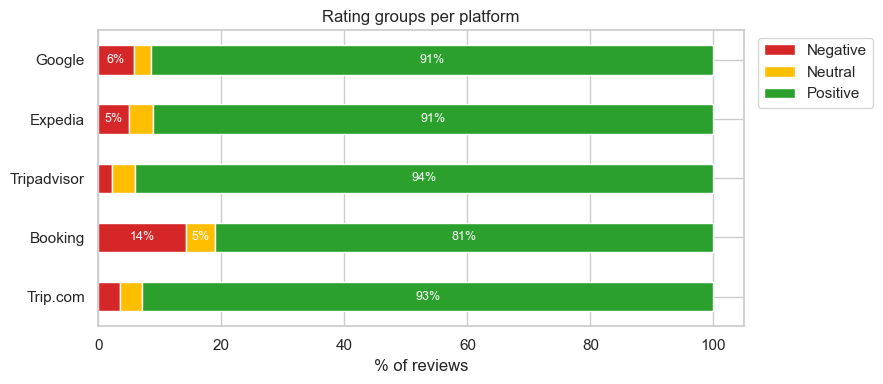

In [27]:
# Share of positive / neutral / negative reviews per platform (100% stacked bars)
shares = (
    pd.crosstab(reviews["source"], reviews["rating_group"], normalize="index")
    .reindex(PLATFORMS) * 100
)

ax = shares.plot(kind="barh", stacked=True, figsize=(9, 4),
                 color=[GROUP_COLOURS[c] for c in shares.columns])
ax.set_xlabel("% of reviews")
ax.set_ylabel("")
ax.set_title("Rating groups per platform")
ax.invert_yaxis()
ax.legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left")

# Label each segment larger than 4%
for container in ax.containers:
    ax.bar_label(container, labels=[f"{w:.0f}%" if w > 4 else "" for w in container.datavalues],
                 label_type="center", color="white", fontsize=9)
plt.tight_layout()
plt.show()

**What I see:**
- Guests are very positive overall: the average is **4.62 / 5**, **79%** of reviews are 5 stars and only **5.4%** are negative.
- **Tripadvisor** is the most positive platform (4.81, 91% five-star).
- **Booking** is the least positive (4.18, 14% negative). Its guests are mostly foreign (see 6.4), and it is also the smallest sample (42 reviews), so I treat this carefully.

#### Star distribution on each platform's own scale
The rating groups above hide how each platform's scale works, so here I plot the full distribution of scores on each platform's original scale (1-5 or 1-10).

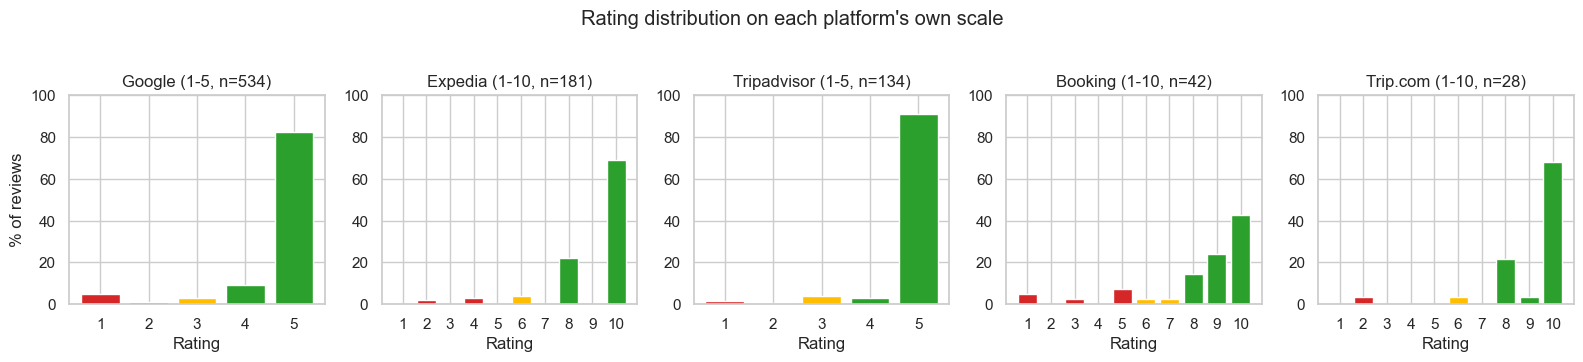

In [28]:
# Star distribution on each platform's own scale (1-5 or 1-10), as % of that platform's reviews
fig, axes = plt.subplots(1, len(PLATFORMS), figsize=(16, 3.5))

for ax, platform in zip(axes, PLATFORMS):
    data = reviews[reviews["source"] == platform]
    scale = int(data["rating_scale"].iloc[0])
    counts = (data["rating_raw"].round().value_counts(normalize=True)
              .reindex(range(1, scale + 1), fill_value=0) * 100)
    # Same colours as the rating groups: red = negative, yellow = neutral, green = positive
    colours = ["#d62728" if s <= scale * 0.5 else "#ffbf00" if s <= scale * 0.7 else "#2ca02c"
               for s in counts.index]
    ax.bar(counts.index, counts.values, color=colours)
    ax.set_xticks(counts.index)
    ax.set_ylim(0, 100)
    ax.set_title(f"{platform} (1-{scale}, n={len(data)})")
    ax.set_xlabel("Rating")
axes[0].set_ylabel("% of reviews")

plt.suptitle("Rating distribution on each platform's own scale", y=1.03)
plt.tight_layout()
plt.show()

In [29]:
# Same data as a table: % of reviews per star level on the common 1-5 scale
stars = reviews["rating_5"].round().clip(1, 5).astype(int)
(pd.crosstab(reviews["source"], stars, normalize="index") * 100).reindex(PLATFORMS).round(1)

rating_5,1,2,3,4,5
source,,,,,
Google,4.7,1.1,2.8,9.0,82.4
Expedia,2.2,2.8,3.9,22.1,69.1
Tripadvisor,1.5,0.7,3.7,3.0,91.0
Booking,4.8,9.5,2.4,40.5,42.9
Trip.com,3.6,0.0,3.6,25.0,67.9


**What I see:**
- On every platform the distribution is heavily skewed towards the top score: most guests give the maximum, and only a small group gives very low scores.
- **Expedia only uses even numbers (2, 4, 6, 8, 10)**: guests actually rate 1-5 stars and Expedia doubles the score, so its "1-10" scale is really a 5-star scale.
- **Booking is the only platform where guests use the full 1-10 range** (many 8s and 9s, only 43% give 10). Part of Booking's lower average in 6.1 is therefore a **scale effect**: a 9/10 on Booking becomes 4.5 on the common 1-5 scale, while a satisfied Google guest simply clicks 5 stars. So I should not conclude that Booking guests had a worse experience based on the average alone.

### 6.2 Changes over the years
Next I check how the average rating and the share of negative reviews changed from 2020 to 2026, first for all platforms combined and then per platform.

In [30]:
yearly = reviews.groupby("year").agg(
    reviews=("rating_5", "size"),
    avg_rating=("rating_5", "mean"),
    pct_negative=("rating_group", lambda s: (s == "Negative").mean() * 100),
).round(2)
yearly

,reviews,avg_rating,pct_negative
year,,,
2020,39,4.87,0.00
2021,175,4.93,0.00
2022,180,4.76,2.78
2023,127,4.41,7.87
2024,176,4.47,7.39
2025,110,4.41,10.00
2026,112,4.48,9.82


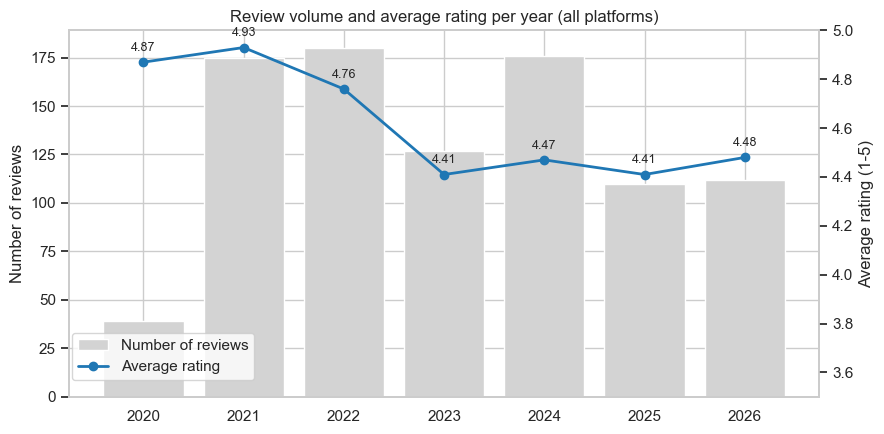

In [31]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))

# Bars: number of reviews per year (left axis)
ax1.bar(yearly.index, yearly["reviews"], color="lightgrey", label="Number of reviews")
ax1.set_ylabel("Number of reviews")

# Line: average rating per year (right axis)
ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly["avg_rating"], marker="o", color="#1f77b4", linewidth=2, label="Average rating")
for x, y in zip(yearly.index, yearly["avg_rating"]):
    ax2.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax2.set_ylim(3.5, 5)
ax2.set_ylabel("Average rating (1-5)")
ax2.grid(False)

ax1.set_title("Review volume and average rating per year (all platforms)")
fig.legend(loc="lower left", bbox_to_anchor=(0.08, 0.12))
plt.tight_layout()
plt.show()

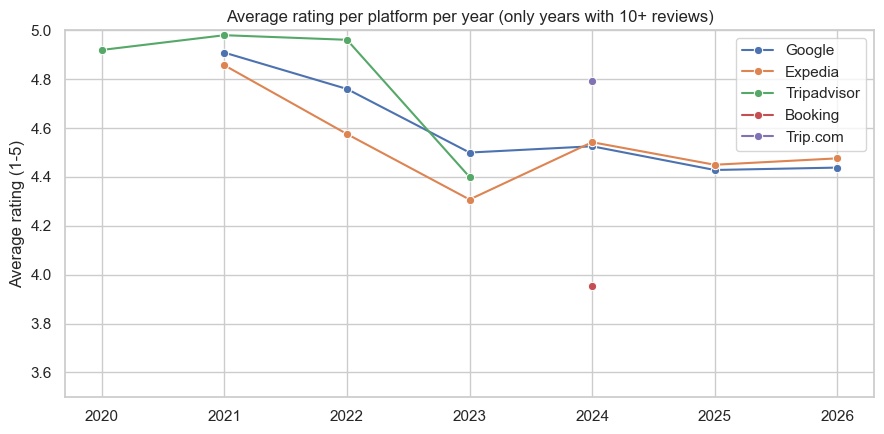

In [32]:
# Average rating per platform per year; only year/platform combinations with 10+ reviews are shown
MIN_REVIEWS = 10
by_platform = reviews.groupby(["year", "source"])["rating_5"].agg(["mean", "size"]).reset_index()
by_platform = by_platform[by_platform["size"] >= MIN_REVIEWS]

plt.figure(figsize=(9, 4.5))
sns.lineplot(data=by_platform, x="year", y="mean", hue="source", hue_order=PLATFORMS, marker="o")
plt.ylim(3.5, 5)
plt.ylabel("Average rating (1-5)")
plt.xlabel("")
plt.title(f"Average rating per platform per year (only years with {MIN_REVIEWS}+ reviews)")
plt.legend(title="")
plt.tight_layout()
plt.show()

**What I see:**
- There is a **clear drop in ratings**: from **4.93 in 2021** to **4.41 in 2023**, and it has stayed around 4.4-4.5 since.
- The share of negative reviews rose from **0% (2020-2021)** to about **10% (2025-2026)**.
- The drop appears on **every platform** (e.g. Google 4.91 → 4.44, Tripadvisor 4.98 → 4.40, Expedia 4.86 → 4.31), so it is a real change in guest experience, not just a change in which platforms guests used.
- In Section 8 I will check which topics (breakfast, cleanliness, staff…) became more negative after 2022 to explain this drop.

#### Is the rating drop statistically significant?
To check that the drop is not just random variation, I compare ratings from 2020-2022 with 2023-2026 using a Mann-Whitney U test. I use this test rather than a t-test because ratings are not normally distributed (most are 5 stars).

In [33]:
# Compare ratings before (2020-2022) and after (2023-2026) the drop
early = reviews.loc[reviews["year"] <= 2022, "rating_5"]
late = reviews.loc[reviews["year"] >= 2023, "rating_5"]

stat, p_value = mannwhitneyu(early, late, alternative="greater")
print(f"2020-2022: {early.mean():.2f} average from {len(early)} reviews")
print(f"2023-2026: {late.mean():.2f} average from {len(late)} reviews")
print(f"Mann-Whitney U test p-value: {p_value:.2e}")
print("Significant drop" if p_value < 0.05 else "No significant difference")

2020-2022: 4.84 average from 394 reviews
2023-2026: 4.45 average from 525 reviews
Mann-Whitney U test p-value: 4.29e-11
Significant drop


#### Which parts of the stay dropped the most?
Google and Expedia guests also score specific parts of their stay. Comparing these sub-ratings before and after 2023 shows whether the drop comes from one area or from the whole experience.

In [34]:
reviews["period"] = np.where(reviews["year"] <= 2022, "2020-2022", "2023-2026")
sub_cols = ["sub_rooms", "sub_service", "sub_location", "sub_cleanliness", "sub_condition", "sub_amenities"]

# Only Google and Expedia have enough sub-ratings; cells with fewer than 10 scores are hidden
sub_period = reviews[reviews["source"].isin(["Google", "Expedia"])] \
    .groupby(["source", "period"])[sub_cols].agg(["mean", "count"])
means = sub_period.xs("mean", axis=1, level=1).round(2)
counts = sub_period.xs("count", axis=1, level=1)
means[counts >= 10]

sub_rooms  sub_service  sub_location  sub_cleanliness  \
source  period                                                             
Expedia 2020-2022       4.74         4.70           NaN             4.79   
        2023-2026       4.43         4.41           NaN             4.52   
Google  2020-2022       4.89         4.88          4.89              NaN   
        2023-2026       4.55         4.46          4.60              NaN   

                   sub_condition  sub_amenities  
source  period                                   
Expedia 2020-2022           4.77            NaN  
        2023-2026           4.49           4.44  
Google  2020-2022            NaN            NaN  
        2023-2026            NaN            NaN

**What I see:**
- The drop is **statistically significant** (average 4.84 → 4.45, p < 0.001), so it is not random variation.
- **Every sub-rating fell** by about 0.3-0.4 points on both platforms. On Google, **service** dropped the most (4.88 → 4.46), followed by rooms (4.89 → 4.55) and location (4.89 → 4.60). On Expedia, service, rooms, cleanliness and condition all dropped by about 0.3.
- Since even location dropped (and the hotel didn't move), part of the fall may reflect **higher expectations** as the hotel became more expensive or better known, not only a decline in quality. Service stands out as the biggest drop, and the topic analysis in Section 8 will show what guests complain about.

### 6.3 Seasonality
Here I look at when guests post reviews and whether satisfaction differs by month and season. The posting date is used as a close proxy for the stay date.

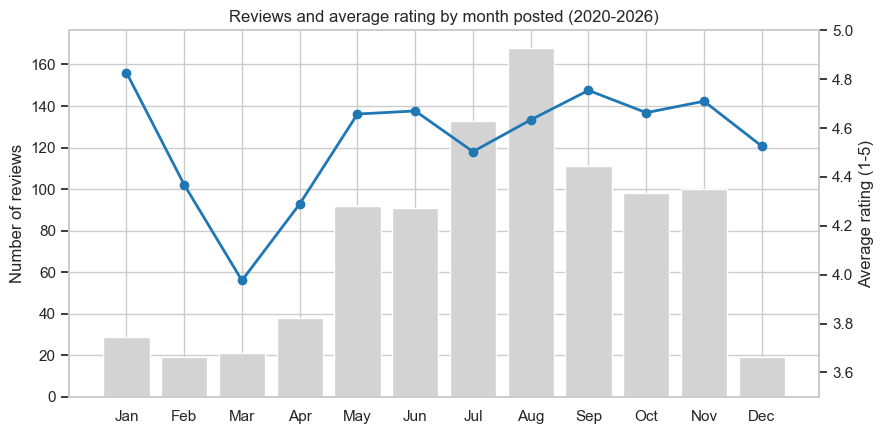

In [35]:
# Reviews and average rating by month of the year (all years combined)
monthly = reviews.groupby("month").agg(
    reviews=("rating_5", "size"),
    avg_rating=("rating_5", "mean"),
)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(monthly.index, monthly["reviews"], color="lightgrey")
ax1.set_xticks(range(1, 13), month_names)
ax1.set_ylabel("Number of reviews")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["avg_rating"], marker="o", color="#1f77b4", linewidth=2)
ax2.set_ylim(3.5, 5)
ax2.set_ylabel("Average rating (1-5)")
ax2.grid(False)

ax1.set_title("Reviews and average rating by month posted (2020-2026)")
plt.tight_layout()
plt.show()

In [36]:
season_order = ["Spring", "Summer", "Autumn", "Winter"]
reviews.groupby("season").agg(
    reviews=("rating_5", "size"),
    avg_rating=("rating_5", "mean"),
    pct_negative=("rating_group", lambda s: (s == "Negative").mean() * 100),
).reindex(season_order).round(2)

,reviews,avg_rating,pct_negative
season,,,
Spring,151,4.47,9.27
Summer,392,4.60,6.38
Autumn,309,4.71,1.94
Winter,67,4.61,7.46


**What I see:**
- **Summer** is the busiest season (392 reviews, 43% of the total).
- **Autumn** has the happiest guests (4.71, only 1.9% negative).
- **Spring** has the lowest satisfaction (4.47, 9.3% negative). This is worth checking in the topic analysis, e.g. whether the outdoor pool or other facilities are not yet open.

### 6.4 Who reviews the hotel: languages and travel groups
I group review languages into Turkish, English, other foreign languages and star-only reviews (no text), and compare ratings across these groups and across travel groups.

In [37]:
def language_group(lang):
    """Turkish, English, other foreign languages, or no text (star-only review)."""
    if pd.isna(lang):
        return "No text"
    if lang == "tr":
        return "Turkish"
    if lang == "en":
        return "English"
    return "Other foreign"

reviews["language_group"] = reviews["language"].map(language_group)

reviews.groupby("language_group").agg(
    reviews=("rating_5", "size"),
    avg_rating=("rating_5", "mean"),
    pct_negative=("rating_group", lambda s: (s == "Negative").mean() * 100),
).sort_values("reviews", ascending=False).round(2)

,reviews,avg_rating,pct_negative
language_group,,,
Turkish,506,4.63,5.34
English,208,4.65,5.29
Other foreign,117,4.48,8.55
No text,88,4.61,2.27


In [38]:
# Language mix per platform (% of each platform's reviews)
(pd.crosstab(reviews["source"], reviews["language_group"], normalize="index") * 100) \
    .reindex(PLATFORMS).round(1)

language_group,English,No text,Other foreign,Turkish
source,,,,
Google,12.9,16.5,9.4,61.2
Expedia,33.1,0.0,14.4,52.5
Tripadvisor,41.0,0.0,6.0,53.0
Booking,35.7,0.0,59.5,4.8
Trip.com,32.1,0.0,28.6,39.3


In [39]:
# Travel groups: "Unknown" and "Other" mean the platform did not record it, so I leave them out
travel = reviews[~reviews["travel_group"].isin(["Unknown", "Other"])].groupby("travel_group").agg(
    reviews=("rating_5", "size"),
    avg_rating=("rating_5", "mean"),
    pct_negative=("rating_group", lambda s: (s == "Negative").mean() * 100),
).sort_values("reviews", ascending=False).round(2)
travel

,reviews,avg_rating,pct_negative
travel_group,,,
Family,240,4.64,5.00
Couple,133,4.59,5.26
Friends,101,4.61,6.93
Solo,19,4.61,5.26
Business,3,4.67,0.00


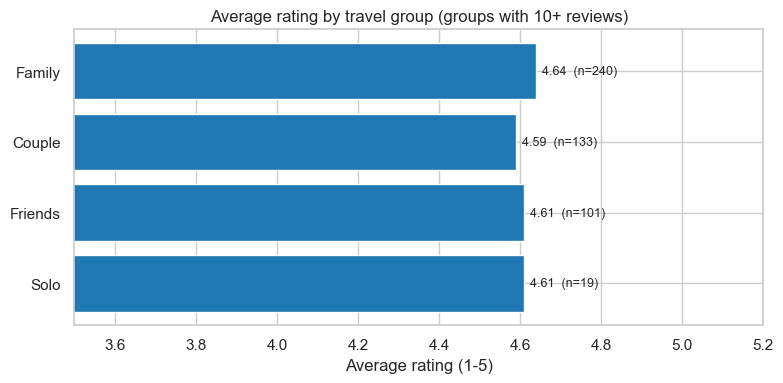

In [40]:
plot_data = travel[travel["reviews"] >= 10]   # skip very small groups

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(plot_data.index, plot_data["avg_rating"], color="#1f77b4")
ax.bar_label(bars, labels=[f"{r:.2f}  (n={n})" for r, n in zip(plot_data["avg_rating"], plot_data["reviews"])],
             padding=4, fontsize=9)
ax.set_xlim(3.5, 5.2)
ax.invert_yaxis()
ax.set_xlabel("Average rating (1-5)")
ax.set_title("Average rating by travel group (groups with 10+ reviews)")
plt.tight_layout()
plt.show()

**What I see:**
- Most reviews are in **Turkish (55%)**, followed by English (23%). Domestic guests are the core market.
- Turkish and English-speaking guests are equally satisfied (4.63 vs 4.65), but **guests writing in other languages are less satisfied** (4.48, 8.6% negative).
- **Booking** is mainly used by foreign guests (60% other languages, only 5% Turkish), which helps explain its lower rating in 6.1.
- **Travel groups** (families, couples, friends, solo) all rate the hotel similarly (4.59-4.64), so the type of trip does not drive satisfaction.

### 6.5 Owner replies
Replying to reviews shows future guests that the hotel listens. Here I check how often the hotel replies, whether it replies more to negative reviews, and how this changed over time.

In [41]:
# Reply rate per platform
reviews.groupby("source").agg(
    reviews=("has_reply", "size"),
    replies=("has_reply", "sum"),
    reply_rate_pct=("has_reply", lambda s: s.mean() * 100),
).reindex(PLATFORMS).round(1)

,reviews,replies,reply_rate_pct
source,,,
Google,534,294,55.1
Expedia,181,80,44.2
Tripadvisor,134,109,81.3
Booking,42,0,0.0
Trip.com,28,10,35.7


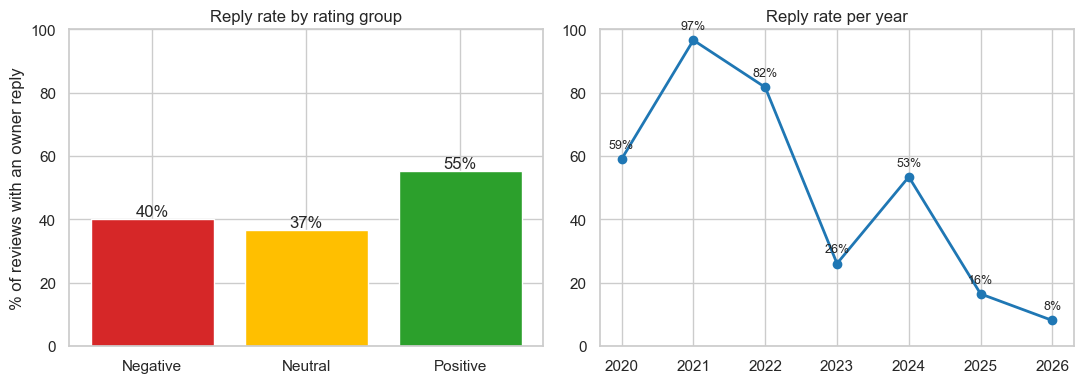

In [42]:
# Does the hotel reply more to negative reviews? Has the reply rate changed over the years?
by_group = reviews.groupby("rating_group", observed=True)["has_reply"].mean().mul(100).round(1)
by_year = reviews.groupby("year")["has_reply"].mean().mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(by_group.index.astype(str), by_group.values, color=[GROUP_COLOURS[g] for g in by_group.index])
axes[0].bar_label(axes[0].containers[0], fmt="%.0f%%")
axes[0].set_ylim(0, 100)
axes[0].set_ylabel("% of reviews with an owner reply")
axes[0].set_title("Reply rate by rating group")

axes[1].plot(by_year.index, by_year.values, marker="o", color="#1f77b4", linewidth=2)
for x, y in zip(by_year.index, by_year.values):
    axes[1].annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
axes[1].set_ylim(0, 100)
axes[1].set_title("Reply rate per year")

plt.tight_layout()
plt.show()

**What I see:**
- Reply rates differ a lot by platform: **Tripadvisor 81%**, Google 55%, Expedia 44%, Trip.com 36% and **Booking 0%**.
- The hotel replies **less to negative reviews (40%)** than to positive ones (55%), which is the opposite of best practice.
- The reply rate has **collapsed**: from **97% in 2021** to only **8% in 2026**. This happened in the same period as the rating drop in 6.2.

### 6.6 Review length
Finally, I compare how much guests write depending on their rating (only reviews with text).

In [43]:
# Only reviews with text
with_text = reviews[reviews["word_count"] > 0]

with_text.groupby("rating_group", observed=True)["word_count"].agg(["count", "median", "mean"]).round(1)

,count,median,mean
rating_group,,,
Negative,43,109.0,143.3
Neutral,21,57.0,127.1
Positive,677,47.0,59.3


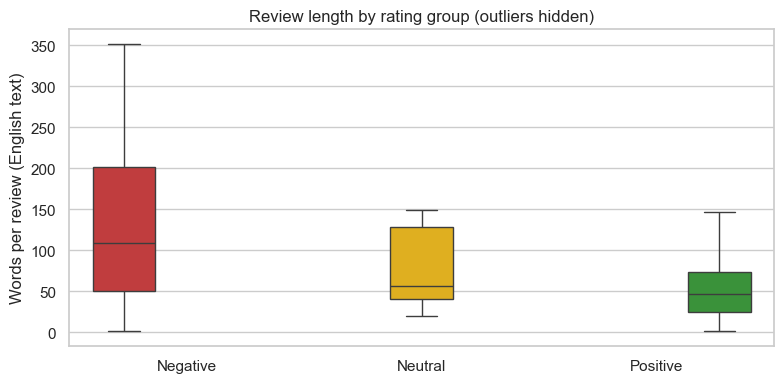

In [44]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=with_text, x="rating_group", y="word_count", hue="rating_group",
            palette=GROUP_COLOURS, showfliers=False, legend=False)
plt.xlabel("")
plt.ylabel("Words per review (English text)")
plt.title("Review length by rating group (outliers hidden)")
plt.tight_layout()
plt.show()

**What I see:**
- Unhappy guests write **more than twice as much**: negative reviews have a median of **109 words**, compared with **47** for positive reviews.
- So although negative reviews are only about 5% of the total, they contain detailed explanations of what went wrong, which is valuable input for the topic analysis in Section 8.

## 7. Sentiment Analysis
In this section I measure how positive or negative each review's **text** is, and compare it with the **star rating** the guest gave.

I use `cardiffnlp/twitter-roberta-base-sentiment-latest`, a free pre-trained RoBERTa model from Hugging Face that labels text as negative, neutral or positive. From its probabilities I create a **sentiment score** from −1 (very negative) to +1 (very positive).

I score sentiment at two levels:
- **Review level:** the overall tone of each review, to compare with its stars
- **Sentence level:** each sentence separately, to find complaints hidden inside positive reviews. These sentences are also the input for the topic analysis in Section 8.

### 7.1 Load the sentiment model
The model is downloaded once (~500 MB). Scores are cached in `data/sentiment_cache.csv`, so every text is only scored once.

In [45]:
import re
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

SENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Download (first time only, ~500 MB) and load the model
sent_tokenizer = AutoTokenizer.from_pretrained(SENT_MODEL)
sent_model = AutoModelForSequenceClassification.from_pretrained(SENT_MODEL)
sent_model.eval()
LABELS = [sent_model.config.id2label[i].lower() for i in range(sent_model.config.num_labels)]
print("Model labels:", LABELS)

# Cache: text -> probabilities, so each text is only scored once
SENT_CACHE_PATH = os.path.join(DATA_DIR, "sentiment_cache.csv")
if os.path.exists(SENT_CACHE_PATH):
    sent_cache = pd.read_csv(SENT_CACHE_PATH, index_col=0).to_dict(orient="index")
else:
    sent_cache = {}

def save_sent_cache():
    pd.DataFrame.from_dict(sent_cache, orient="index").to_csv(SENT_CACHE_PATH, encoding="utf-8-sig")

def score_texts(texts, batch_size=32):
    """Return a DataFrame with negative/neutral/positive probabilities for each text."""
    todo = [t for t in dict.fromkeys(texts) if t not in sent_cache]   # unique, not yet scored
    for i in range(0, len(todo), batch_size):
        batch = todo[i:i + batch_size]
        encoded = sent_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512)
        with torch.no_grad():
            probs = torch.softmax(sent_model(**encoded).logits, dim=-1).numpy()
        for text, p in zip(batch, probs):
            sent_cache[text] = dict(zip(LABELS, p.round(4)))
        if (i // batch_size) % 10 == 0:
            print(f"  scored {min(i + batch_size, len(todo))}/{len(todo)}")
    save_sent_cache()
    return pd.DataFrame([sent_cache[t] for t in texts])[["negative", "neutral", "positive"]]

def split_sentences(text):
    """Split a review into sentences."""
    parts = re.split(r"(?<=[.!?])\s+|\n+", str(text))
    return [p.strip() for p in parts if p.strip()]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model labels: ['negative', 'neutral', 'positive']


### 7.2 Score every review
For each review with text I store the three probabilities, the sentiment score (positive minus negative probability) and the most likely label.

In [46]:
has_text = reviews["text_en"].notna()
scores = score_texts(reviews.loc[has_text, "text_en"].tolist())

# Probabilities, one overall score from -1 to +1, and the most likely label
reviews.loc[has_text, ["sent_negative", "sent_neutral", "sent_positive"]] = scores.values
reviews["sentiment_score"] = reviews["sent_positive"] - reviews["sent_negative"]
reviews.loc[has_text, "sentiment_label"] = scores.idxmax(axis=1).str.capitalize().values

print(reviews["sentiment_label"].value_counts())
reviews.loc[has_text, ["source", "rating_5", "sentiment_label", "sentiment_score", "text_en"]].head()

sentiment_label
Positive    675
Negative     47
Neutral      19
Name: count, dtype: int64


,source,rating_5,sentiment_label,sentiment_score,text_en
0,Google,5.0,Positive,0.9835,"We had a wonderful stay at this hotel. Everything was clean, comfortable, and beautifully arranged. The atmosphere was amazing, and the staff were very friendly and helpful throughout our stay. Th..."
1,Google,5.0,Positive,0.9802,"Highly recommend this hotel! The staff were very nice and friendly, the breakfast was really good, and the hotel was clean. It’s also only about 5 minutes away from downtown Cappadocia. Our flight..."
2,Google,5.0,Positive,0.9329,"A very well-located hotel, close to the heart of Göremes without the noise.\nThe hotel is very quiet and very clean.\nThe restaurant overlooks a lovely swimming pool and offers a magnificent view ..."
3,Google,5.0,Positive,0.9829,"It was a wonderful accommodation experience. I would definitely recommend it for its cleanliness, friendly staff, and quality service 🌸 The pool was clean, watching the balloons from the terrace w..."
4,Google,5.0,Positive,0.9805,"We had such a great stay, it was sad to leave. Everybody was sweet and helpful, and the location is perfect to walk in town AND enjoy the balloons in the morning. Our room was amazing and clean. B..."


### 7.3 Can I trust the model?
Before using the scores, I check them in two ways:
1. **Booking's liked/disliked texts:** guests wrote these in separate boxes, so I already know which texts are positive and which are negative. A good model should label most "liked" texts positive and most "disliked" texts negative.
2. **Correlation with stars:** text sentiment should generally rise with the star rating. I use Spearman's correlation because ratings are ordinal.

In [47]:
# Booking's liked/disliked texts are already labelled by the guests themselves
liked = reviews["liked_en"].dropna().tolist()
disliked = reviews["disliked_en"].dropna().tolist()
liked_pred = score_texts(liked).idxmax(axis=1)
disliked_pred = score_texts(disliked).idxmax(axis=1)

pd.DataFrame({
    "Booking 'liked' texts": liked_pred.value_counts(normalize=True) * 100,
    "Booking 'disliked' texts": disliked_pred.value_counts(normalize=True) * 100,
}).reindex(["positive", "neutral", "negative"]).fillna(0).round(1)

,Booking 'liked' texts,Booking 'disliked' texts
positive,83.3,7.1
neutral,12.5,35.7
negative,4.2,57.1


Spearman correlation between stars and text sentiment: 0.55 (p = 5.7e-61)


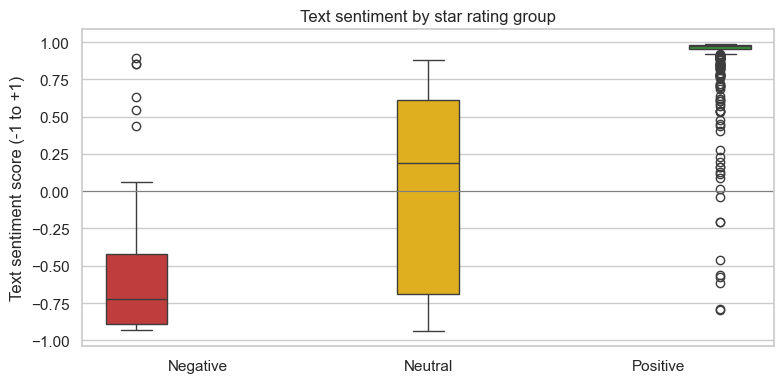

In [48]:
from scipy.stats import spearmanr

scored = reviews[has_text].copy()   # reviews with text only
rho, p = spearmanr(scored["rating_5"], scored["sentiment_score"])
print(f"Spearman correlation between stars and text sentiment: {rho:.2f} (p = {p:.1e})")

plt.figure(figsize=(8, 4))
sns.boxplot(data=scored, x="rating_group", y="sentiment_score", hue="rating_group",
            palette=GROUP_COLOURS, legend=False)
plt.axhline(0, color="grey", linewidth=0.8)
plt.xlabel("")
plt.ylabel("Text sentiment score (-1 to +1)")
plt.title("Text sentiment by star rating group")
plt.tight_layout()
plt.show()

**What I see:**
- The model agrees well with the guests' own labels: **83%** of Booking "liked" texts are labelled positive, and only **7%** of "disliked" texts are labelled positive (57% negative, 36% neutral, as many complaints are written in a calm, factual tone).
- Text sentiment and stars are clearly related (**Spearman ρ = 0.55, p < 0.001**). This is strong, but not perfect, because stars and text capture slightly different things.
- So I consider the model reliable enough for comparing groups, years and topics.

### 7.4 Do the stars match the text?
Here I compare what the stars say with what the text says. In the heatmap, each row is a star rating group and shows how that group's texts were labelled by the model. A perfect match would put 100% on the diagonal.

I then count **clear mismatches**, where stars and text point in opposite directions:
- **High stars, negative text:** e.g. 5 stars but the review mostly describes problems
- **Low stars, positive text:** e.g. 1 star but a friendly text (sometimes a guest clicking the wrong star)

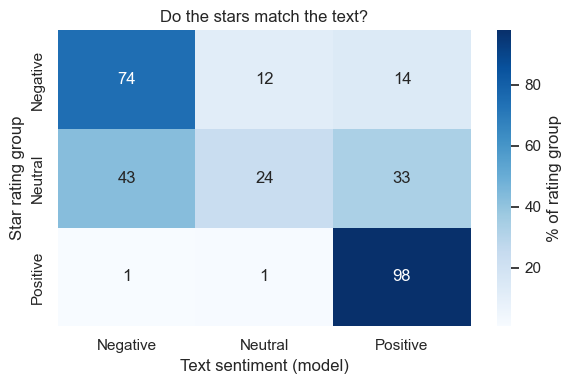

In [49]:
# Rows = what the stars say, columns = what the text says (% of each rating group)
match = pd.crosstab(scored["rating_group"], scored["sentiment_label"], normalize="index") \
    .reindex(columns=["Negative", "Neutral", "Positive"]).fillna(0) * 100

plt.figure(figsize=(6, 4))
sns.heatmap(match, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% of rating group"})
plt.xlabel("Text sentiment (model)")
plt.ylabel("Star rating group")
plt.title("Do the stars match the text?")
plt.tight_layout()
plt.show()

In [50]:
# Clear mismatches: stars and text point in opposite directions
scored["mismatch"] = np.select(
    [(scored["rating_group"] == "Positive") & (scored["sentiment_label"] == "Negative"),
     (scored["rating_group"] == "Negative") & (scored["sentiment_label"] == "Positive")],
    ["High stars, negative text", "Low stars, positive text"],
    default="Match / mild difference",
)
scored["mismatch"].value_counts()

mismatch
Match / mild difference      729
Low stars, positive text       6
High stars, negative text      6
Name: count, dtype: int64

### 7.5 Mismatched reviews: a closer look
To understand the mismatches, I read the most extreme examples of each type.

In [51]:
# High stars, negative text (most negative first)
cols = ["source", "year", "rating_5", "sentiment_score", "text_en"]
scored[scored["mismatch"] == "High stars, negative text"].sort_values("sentiment_score")[cols].head(8)

,source,year,rating_5,sentiment_score,text_en
610,Expedia,2025,4.0,-0.7947,"Beautiful view and very careful staff. But 1st hotel in my life to factor the part of a card. It's not very nice, so it's bad enough."
799,Tripadvisor,2022,4.0,-0.7880,"We needed an agenda for the balloon and the reception staff. I didn't speak English!!! The hotel has good external physical structure, but the bathroom it is not good( the shower door makes a terr..."
549,Booking,2024,4.0,-0.6167,Good black Some members of the staff did not really like their attitude to work
130,Google,2025,4.0,-0.5766,"Overall, the hotel was very nice, but paying for a night in Euros and then being told to pay for the water in the room was really unpleasant. For an establishment that only includes breakfast, I t..."
655,Expedia,2024,5.0,-0.5643,"The decorations, the design, it was beautiful, the bed was comfortable, breakfast was bad, and I don't deserve it. It wasn't good. I wish breakfast was perfect, then I could say I'd definitely go ..."
239,Google,2023,4.0,-0.4599,"The hotel is nice, but there's a bit of a staff shortage."


In [52]:
# Low stars, positive text (most positive first)
scored[scored["mismatch"] == "Low stars, positive text"].sort_values("sentiment_score", ascending=False)[cols].head(8)

,source,year,rating_5,sentiment_score,text_en
787,Tripadvisor,2023,2.0,0.8927,"We stayed at the hotel for 2 days due to the holiday. The room quality is not bad, the location of the hotel is very good. Apart from that, considering the quality of the food and the general serv..."
178,Google,2024,2.0,0.8554,"The hotel is very nice and very stylish. The service was absurd; you ask for a drink and it takes 20 minutes to arrive, even for a simple cola. We didn't mind because the staff were very polite. C..."
719,Expedia,2022,2.0,0.8538,Degressive! We arrived in a hotel similar to a hotel (which is looking for...) from an attractive park. We had chosen this place because of the pool. The proximity to the road has been a great del...
538,Booking,2025,2.5,0.6331,"Great location but no other guests at the hotel at the time we were staying, since it is not in the main city it had become quite eerie but the staff did what it could to make our stay warmer."
539,Booking,2024,2.5,0.5438,"Excellent breakfast.\r\nNice hotel personal during the night shift.\r\nClean room and bathroom. \r\nCalm and relaxed atmosphere in the hotel, offering multiple places to sit or lied down and relax..."
127,Google,2025,2.0,0.4359,"The only positive aspect of the hotel is the opportunity to observe the hot air balloons from very close up.\n\nCons:\n- If you haven't booked a room through one of the hotel's partner locations, ..."


**What I see:**
- Stars and text **almost always agree**: only **12 of 741** reviews (1.6%) are clear mismatches.
- Most "high stars, negative text" reviews are **mixed reviews**: the guest liked the stay overall but focuses the text on one problem, e.g. paying extra for water, a staff shortage or poor breakfast.
- Most "low stars, positive text" reviews are also mixed: the guest politely mentions positives ("good location", "polite staff") but gave a low score because of slow service, food quality or feeling isolated.
- A few mismatches were caused by translation errors, which I fixed in Section 4.4.

### 7.6 Does the text confirm the rating drop?
In 6.2 the star ratings dropped after 2022. Here I check whether the review texts show the same trend, by comparing the share of negative reviews per year according to the stars and according to the text.

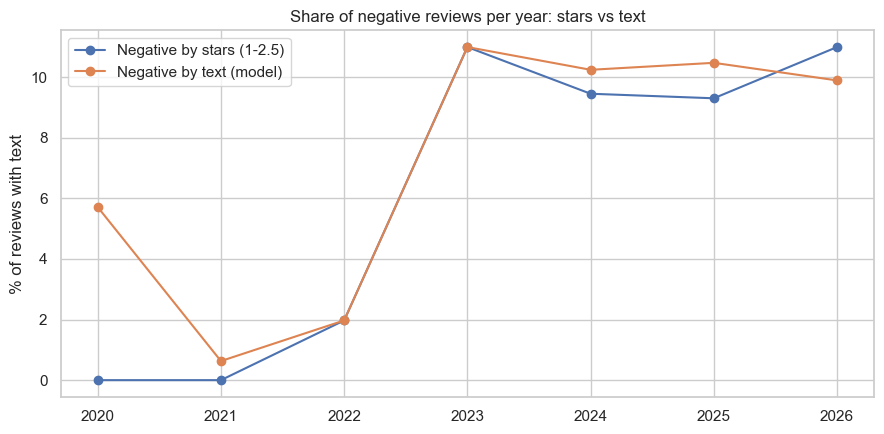

,negative_by_stars,negative_by_text,avg_sentiment
year,,,
2020,0.00,5.71,0.88
2021,0.00,0.63,0.92
2022,1.97,1.97,0.90
2023,10.99,10.99,0.70
2024,9.45,10.24,0.75
2025,9.30,10.47,0.70
2026,10.99,9.89,0.76


In [53]:
# Share of negative reviews per year: by stars vs by text
trend = scored.groupby("year").agg(
    negative_by_stars=("rating_group", lambda s: (s == "Negative").mean() * 100),
    negative_by_text=("sentiment_label", lambda s: (s == "Negative").mean() * 100),
    avg_sentiment=("sentiment_score", "mean"),
).round(2)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(trend.index, trend["negative_by_stars"], marker="o", label="Negative by stars (1-2.5)")
ax.plot(trend.index, trend["negative_by_text"], marker="o", label="Negative by text (model)")
ax.set_ylabel("% of reviews with text")
ax.set_title("Share of negative reviews per year: stars vs text")
ax.legend()
plt.tight_layout()
plt.show()
trend

**What I see:**
- The text **confirms the rating drop**: the share of reviews with negative text went from almost **0-2% in 2021-2022** to about **10-12% from 2023 onwards**, closely following the stars.
- The average text sentiment fell from **0.92 (2021)** to around **0.70-0.76** since 2023.
- Because stars and text tell the same story, the drop reflects a real change in guest experience.

### 7.7 Hidden complaints inside positive reviews
Many guests give 4-5 stars but still mention a problem ("great stay, but breakfast was poor"). The overall review score hides these, so I split every review into sentences and score each sentence separately.

A sentence counts as a **clear complaint** when the model labels it negative with at least 60% probability.

In [54]:
# One row per sentence, keeping the review's details
sentences = (
    scored[["source", "year", "rating_5", "rating_group", "text_en"]]
    .assign(sentence=scored["text_en"].map(split_sentences))
    .explode("sentence")
    .drop(columns="text_en")
    .rename_axis("review_index")
    .reset_index()
)
sentences = sentences[sentences["sentence"].str.split().str.len() >= 3]   # skip fragments like "Thanks."

sent_scores = score_texts(sentences["sentence"].tolist())
sentences[["negative", "neutral", "positive"]] = sent_scores.values
sentences["sentence_label"] = sent_scores.idxmax(axis=1).str.capitalize().values
sentences["sentence_score"] = sentences["positive"] - sentences["negative"]

print(len(sentences), "sentences from", sentences["review_index"].nunique(), "reviews")
sentences["sentence_label"].value_counts()

3866 sentences from 728 reviews


sentence_label
Positive    2552
Neutral      866
Negative     448
Name: count, dtype: int64

In [55]:
# Positive-star reviews that still contain at least one clear complaint
clear_negative = sentences[(sentences["sentence_label"] == "Negative") & (sentences["negative"] >= 0.6)]
scored["has_complaint"] = scored.index.isin(clear_negative["review_index"])

positive_reviews = scored[scored["rating_group"] == "Positive"]
print(f"{positive_reviews['has_complaint'].mean() * 100:.1f}% of positive-star reviews contain at least one complaint")

positive_reviews.groupby("year")["has_complaint"].agg(
    reviews="size", with_complaint="sum", pct_with_complaint=lambda s: s.mean() * 100
).round(1)

10.6% of positive-star reviews contain at least one complaint


,reviews,with_complaint,pct_with_complaint
year,,,
2020,33,3,9.1
2021,158,16,10.1
2022,148,13,8.8
2023,74,11,14.9
2024,112,10,8.9
2025,74,13,17.6
2026,78,6,7.7


In [56]:
# Examples: the strongest complaints written in positive-star reviews
cols = ["source", "year", "rating_5", "negative", "sentence"]
clear_negative[clear_negative["rating_group"] == "Positive"].sort_values("negative", ascending=False)[cols].head(10)

,source,year,rating_5,negative,sentence
2881,Expedia,2022,4.0,0.9367,The most disappointing part is the restaurant.
2675,Expedia,2025,4.0,0.9356,"It's not very nice, so it's bad enough."
4053,Trip.com,2024,4.0,0.9261,The breakfast was particularly disturbing.
2694,Expedia,2024,4.0,0.9189,The breakfast was very disturbing.
411,Google,2025,4.0,0.9179,"- The hotel doesn't have its own activities; we came with a terrible yoga event under the guise of an activity, and we regretted it immensely."
2875,Expedia,2022,5.0,0.9153,One bad thing was the pool was really filthy.
1219,Google,2023,5.0,0.9083,"We reported it to reception, but no one came to fix it for a long time, and we waited, so we had to go back to reception."
2693,Expedia,2024,4.0,0.9075,"The breakfast was very disturbing, especially at night."
1785,Google,2022,4.0,0.9068,Soundproofing was very poor.
3035,Tripadvisor,2024,4.0,0.9043,The outside space including pool was disappointing.


**What I see:**
- **10.6% of positive-star reviews** still contain at least one clear complaint, so the stars alone underestimate how many guests experienced a problem.
- These hidden complaints peaked in **2023 (15%)** and **2025 (18%)**.
- The strongest complaints in 4-5 star reviews are about **breakfast and the restaurant**, **pool cleanliness**, **soundproofing**, **slow response to repair requests** and **paying extra for water**. Section 8 measures how often each of these topics comes up and how it changed over time.

### 7.8 Save the results
I save the reviews with their sentiment scores, and the sentence-level table, which is the input for the topic analysis in Section 8.

In [57]:
reviews.to_csv(os.path.join(DATA_DIR, "reviews_sentiment.csv"), index=False, encoding="utf-8-sig")
sentences.to_csv(os.path.join(DATA_DIR, "sentences_sentiment.csv"), index=False, encoding="utf-8-sig")
print("Saved", len(reviews), "reviews and", len(sentences), "sentences")

Saved 919 reviews and 3866 sentences


**Section 7 summary:**
- The sentiment model is reliable (83% of Booking "liked" texts labelled positive; ρ = 0.55 with stars).
- Stars and text almost always agree (only 1.6% clear mismatches), and the text confirms the rating drop after 2022.
- About 1 in 10 positive-star reviews still contains a complaint, mainly about breakfast/restaurant, pool cleanliness, soundproofing, slow repairs and paying extra for water.

## 8. Topic Analysis
In this section I find out **what** guests talk about (breakfast, cleanliness, view, staff…) and **how they feel** about each topic, using the sentence-level sentiment from Section 7.

My approach:
1. I define a **topic dictionary**: a list of keywords for each topic.
2. I tag every sentence with the topics it mentions (a sentence can have several).
3. For each topic I measure how often it is mentioned, how positive or negative those sentences are, how much it affects the star rating, and how this changed over the years.

I chose a keyword dictionary rather than an automatic topic model because the topics I care about are known in advance, and keywords are transparent and easy to check.

### 8.0 Load the sentiment results
I reload the files saved in Section 7 so this section can run on its own.

In [58]:
# Reload the results from Section 7 so this section can run on its own
reviews = pd.read_csv(os.path.join(DATA_DIR, "reviews_sentiment.csv"))
sentences = pd.read_csv(os.path.join(DATA_DIR, "sentences_sentiment.csv"))
print(len(reviews), "reviews,", len(sentences), "sentences")

919 reviews, 3866 sentences


### 8.1 Topic dictionary
Each topic has a list of keyword stems. A stem matches at the start of a word, so "clean" also finds "cleanliness" and "cleaned", and "balloon" also finds "balloons".

In [59]:
# Topic dictionary: keyword stems per topic (matched at the start of a word, so "clean" also finds "cleanliness")
TOPICS = {
    "Breakfast":       ["breakfast", "buffet"],
    "Food & drinks":   ["restaurant", "dinner", "lunch", "food", "meal", "menu", r"bar\b", "drink",
                        "coffee", r"tea\b", "chef", "cook", "dish"],
    "Cleanliness":     ["clean", "dirt", "filth", "hygien", "dust", "smell", "stain", "spotless", "tidy",
                        "housekeep", "sewer"],
    "View & balloons": ["view", "balloon", "terrace", "roof", "sunrise", "panoram", "scener"],
    "Staff & service": ["staff", "service", "reception", "employee", "personnel", "manager", "hospitalit",
                        "welcom", "attentive", "rude", "polite", "team"],
    "Rooms":           ["room", r"bed", "bathroom", "shower", "toilet", "pillow", "mattress", "towel",
                        "spacious", "suite", "balcon", "minibar"],
    "Location":        ["location", "located", "centre", "center", "walk", "distance", "downtown", "town",
                        "g[oö]reme", "close to", "far from", "parking", "car park"],
    "Pool & spa":      ["pool", r"spa\b", "sauna", "hamam", "hammam", "jacuzzi", "swim", "massage"],
    "Value & price":   ["price", "value", "expensive", "cheap", "worth", "money", "pay", "paid", "charg",
                        r"extra\b", "cost", r"fee\b", "afford"],
    "Noise & sleep":   ["noise", "noisy", "quiet", "loud", "soundproof", "sleep", r"dog", "bark", "calm",
                        "peaceful"],
}

# One regular expression per topic
TOPIC_PATTERNS = {topic: re.compile(r"\b(?:" + "|".join(words) + ")", re.IGNORECASE)
                  for topic, words in TOPICS.items()}

pd.DataFrame({"keywords": {t: ", ".join(w).replace("\\b", "") for t, w in TOPICS.items()}})

,keywords
Breakfast,"breakfast, buffet"
Food & drinks,"restaurant, dinner, lunch, food, meal, menu, bar, drink, coffee, tea, chef, cook, dish"
Cleanliness,"clean, dirt, filth, hygien, dust, smell, stain, spotless, tidy, housekeep, sewer"
View & balloons,"view, balloon, terrace, roof, sunrise, panoram, scener"
Staff & service,"staff, service, reception, employee, personnel, manager, hospitalit, welcom, attentive, rude, polite, team"
Rooms,"room, bed, bathroom, shower, toilet, pillow, mattress, towel, spacious, suite, balcon, minibar"
Location,"location, located, centre, center, walk, distance, downtown, town, g[oö]reme, close to, far from, parking, car park"
Pool & spa,"pool, spa, sauna, hamam, hammam, jacuzzi, swim, massage"
Value & price,"price, value, expensive, cheap, worth, money, pay, paid, charg, extra, cost, fee, afford"
Noise & sleep,"noise, noisy, quiet, loud, soundproof, sleep, dog, bark, calm, peaceful"


### 8.2 Tag each sentence with its topics
I check every sentence against each topic's keywords, then create a long table with one row per sentence-topic mention. I also print two random sentences per topic to check that the keywords catch the right things.

In [60]:
# Tag every sentence with the topics it mentions (one sentence can have several topics)
for topic, pattern in TOPIC_PATTERNS.items():
    sentences[topic] = sentences["sentence"].map(lambda s: bool(pattern.search(str(s))))

topic_names = list(TOPICS)
sentences["n_topics"] = sentences[topic_names].sum(axis=1)
print(f"{(sentences['n_topics'] > 0).mean() * 100:.1f}% of sentences mention at least one topic")

# Long format: one row per (sentence, topic), used in the rest of this section
mentions = sentences.melt(
    id_vars=["review_index", "source", "year", "rating_5", "rating_group", "sentence",
             "sentence_label", "sentence_score", "negative"],
    value_vars=topic_names, var_name="topic", value_name="mentioned",
).query("mentioned").drop(columns="mentioned")

print(len(mentions), "topic mentions")

62.3% of sentences mention at least one topic
3682 topic mentions


In [61]:
# Spot-check: two random sentences per topic, to confirm the keywords catch the right things
mentions.groupby("topic").sample(2, random_state=1)[["topic", "sentence"]]

,topic,sentence
3418,Breakfast,The buffet is serving breakfast.
3846,Breakfast,The breakfast was good enough.
10144,Cleanliness,The closed pool was cold and not very hygienic.
10433,Cleanliness,"Being on the outskirt of the town center makes this hotel a great place to stay, though, for anyone seeking a quiet, comfortable, and clean hotel."
4241,Food & drinks,"I wish dinner was included, thank you ♥️"
6209,Food & drinks,The hotel offered a good buffet breakfast and an all-day bar.
23951,Location,"The most beautiful place in Göreme, spotlessly clean, friendly staff, we enjoyed it very much."
23695,Location,Really nice hotel on the edge of the town with the view.
36476,Noise & sleep,It's a quiet hotel where you can spend time in peace.
35246,Noise & sleep,"The design is extremely stylish, and the location is both central and lovely, away from the crowds and noise."


**What I see:**
- **62%** of sentences mention at least one topic, so the dictionary covers most of what guests write about.
- The spot-check sentences are correctly tagged. A few sentences get an extra tag (e.g. "balloons take off next to your room" also counts as Rooms), which is acceptable because the sentiment of the sentence still applies.

### 8.3 What do guests talk about?
Here I measure the share of reviews (with text) that mention each topic at least once.

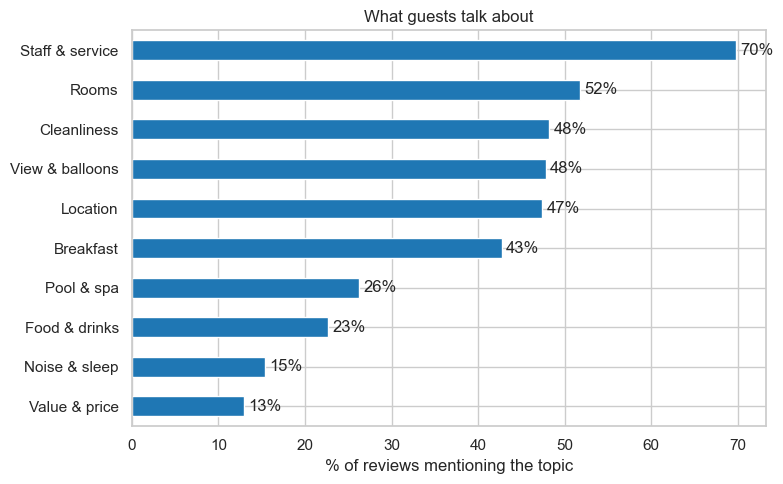

In [62]:
# % of reviews (with text) that mention each topic at least once
reviews_with_text = sentences["review_index"].nunique()
topic_reach = (
    mentions.drop_duplicates(["review_index", "topic"])
    .groupby("topic").size().div(reviews_with_text).mul(100)
    .sort_values()
)

ax = topic_reach.plot(kind="barh", figsize=(8, 5), color="#1f77b4")
ax.bar_label(ax.containers[0], fmt="%.0f%%", padding=3)
ax.set_xlabel("% of reviews mentioning the topic")
ax.set_ylabel("")
ax.set_title("What guests talk about")
plt.tight_layout()
plt.show()

**What I see:**
- **Staff & service** is by far the most discussed topic (**70%** of reviews), followed by rooms (52%), cleanliness (48%), view & balloons (48%), location (47%) and breakfast (43%).
- Pool & spa (26%), food & drinks (23%), noise (15%) and value & price (13%) come up less often.

### 8.4 How do guests feel about each topic?
For each topic I look at the sentiment of the sentences that mention it: the share of positive, neutral and negative mentions.

Then I measure each topic's **impact on the star rating**: the average rating of reviews that mention the topic negatively, compared with reviews that mention it without complaint. A large gap means that a problem with this topic costs the hotel a lot of stars.

In [63]:
# Sentiment of the sentences that mention each topic
topic_sentiment = mentions.groupby("topic").agg(
    mentions=("sentence", "size"),
    pct_positive=("sentence_label", lambda s: (s == "Positive").mean() * 100),
    pct_neutral=("sentence_label", lambda s: (s == "Neutral").mean() * 100),
    pct_negative=("sentence_label", lambda s: (s == "Negative").mean() * 100),
    avg_score=("sentence_score", "mean"),
).round(1).sort_values("pct_negative", ascending=False)
topic_sentiment

,mentions,pct_positive,pct_neutral,pct_negative,avg_score
topic,,,,,
Value & price,157,27.4,36.9,35.7,-0.1
Pool & spa,251,57.4,23.9,18.7,0.4
Food & drinks,224,65.2,17.0,17.9,0.5
Rooms,552,64.3,22.1,13.6,0.5
Breakfast,346,78.9,8.7,12.4,0.6
Cleanliness,413,84.5,5.1,10.4,0.7
Staff & service,718,82.0,8.6,9.3,0.7
Noise & sleep,133,74.4,18.0,7.5,0.6
Location,437,73.0,23.1,3.9,0.7


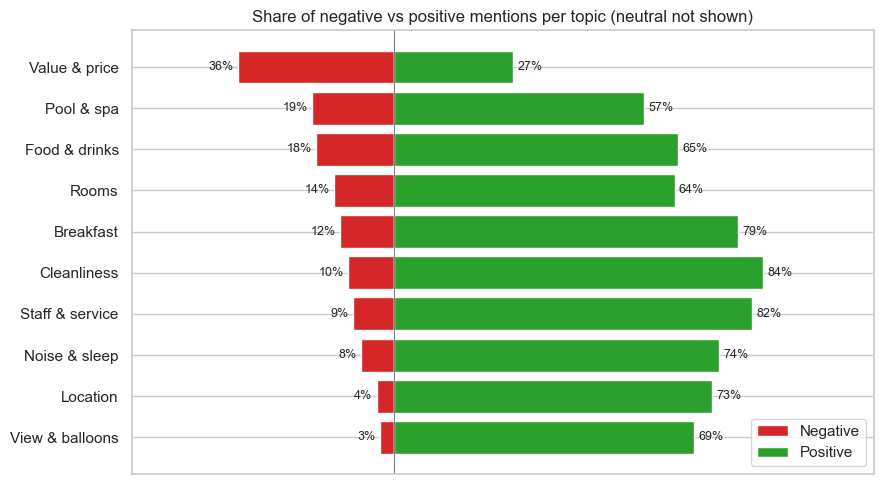

In [64]:
# Diverging bars: negative share to the left, positive share to the right
plot_data = topic_sentiment.sort_values("pct_negative")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data.index, -plot_data["pct_negative"], color=GROUP_COLOURS["Negative"], label="Negative")
ax.barh(plot_data.index, plot_data["pct_positive"], color=GROUP_COLOURS["Positive"], label="Positive")
for y, (neg, pos) in enumerate(zip(plot_data["pct_negative"], plot_data["pct_positive"])):
    ax.text(-neg - 1, y, f"{neg:.0f}%", va="center", ha="right", fontsize=9)
    ax.text(pos + 1, y, f"{pos:.0f}%", va="center", ha="left", fontsize=9)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlim(-60, 110)
ax.set_xticks([])
ax.set_title("Share of negative vs positive mentions per topic (neutral not shown)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [65]:
# Impact on the star rating: average rating of reviews that mention a topic negatively vs not negatively
review_topic = mentions.groupby(["review_index", "topic"]).agg(
    rating_5=("rating_5", "first"),
    any_negative=("sentence_label", lambda s: (s == "Negative").any()),
).reset_index()

negative = review_topic[review_topic["any_negative"]].groupby("topic")["rating_5"]
not_negative = review_topic[~review_topic["any_negative"]].groupby("topic")["rating_5"]
impact = pd.DataFrame({
    "reviews_negative": negative.size(),
    "avg_rating_if_negative": negative.mean(),
    "avg_rating_if_not_negative": not_negative.mean(),
})
impact["rating_gap"] = impact["avg_rating_if_not_negative"] - impact["avg_rating_if_negative"]
impact.round(2).sort_values("rating_gap", ascending=False)

,reviews_negative,avg_rating_if_negative,avg_rating_if_not_negative,rating_gap
topic,,,,
Staff & service,39,2.60,4.87,2.27
Cleanliness,25,2.74,4.89,2.15
Value & price,34,2.38,4.39,2.01
Breakfast,40,2.93,4.85,1.92
Food & drinks,30,3.03,4.91,1.88
Location,16,3.03,4.78,1.75
Rooms,61,3.11,4.84,1.72
Pool & spa,33,3.17,4.78,1.61
Noise & sleep,9,3.44,4.72,1.28


**What I see:**
- **Value & price is the most negative topic** by far: **36%** of mentions are negative and only 27% positive. Guests rarely talk about price, but when they do, it is usually a complaint.
- Next come **pool & spa (19%)**, **food & drinks (18%)**, **rooms (14%)** and **breakfast (12%)**.
- The clear **strengths** are the **view & balloons (3% negative)** and **location (4%)**. Staff and cleanliness are also mostly praised (82-85% positive).
- The **impact on stars** is largest for **staff & service**: reviews with a staff complaint average **2.60 stars**, versus 4.87 without one (a gap of **2.3 stars**). Cleanliness (gap 2.2) and value & price (2.0, lowest average at 2.38) follow. A bad view barely affects ratings (gap 0.9).

### 8.5 Topics over the years
In Section 6 the ratings dropped after 2022. Here I check which topics became more negative, first by comparing the two periods (2020-2022 vs 2023-2026) and then year by year. Years with fewer than 10 mentions of a topic are left blank, because percentages based on so few sentences are unreliable.

In [66]:
# Did topics become more negative after 2022? Compare the two periods from Section 6
mentions["period"] = np.where(mentions["year"] <= 2022, "2020-2022", "2023-2026")

period_neg = mentions.pivot_table(index="topic", columns="period", values="sentence_label",
                                  aggfunc=lambda s: (s == "Negative").mean() * 100).round(1)
period_n = mentions.pivot_table(index="topic", columns="period", values="sentence", aggfunc="size")
period_neg["change_pts"] = period_neg["2023-2026"] - period_neg["2020-2022"]
period_neg = period_neg.join(period_n.add_prefix("n "))
period_neg.sort_values("change_pts", ascending=False)

period,2020-2022,2023-2026,change_pts,n 2020-2022,n 2023-2026
topic,,,,,
Value & price,11.6,44.7,33.1,43,114
Food & drinks,9.5,25.2,15.7,105,119
Pool & spa,9.4,24.5,15.1,96,155
Rooms,6.6,18.4,11.8,226,326
Cleanliness,4.5,16.0,11.5,201,212
Staff & service,5.2,13.6,8.4,365,353
Breakfast,7.6,15.9,8.3,145,201
Noise & sleep,4.0,9.6,5.6,50,83
Location,1.5,6.0,4.5,202,235


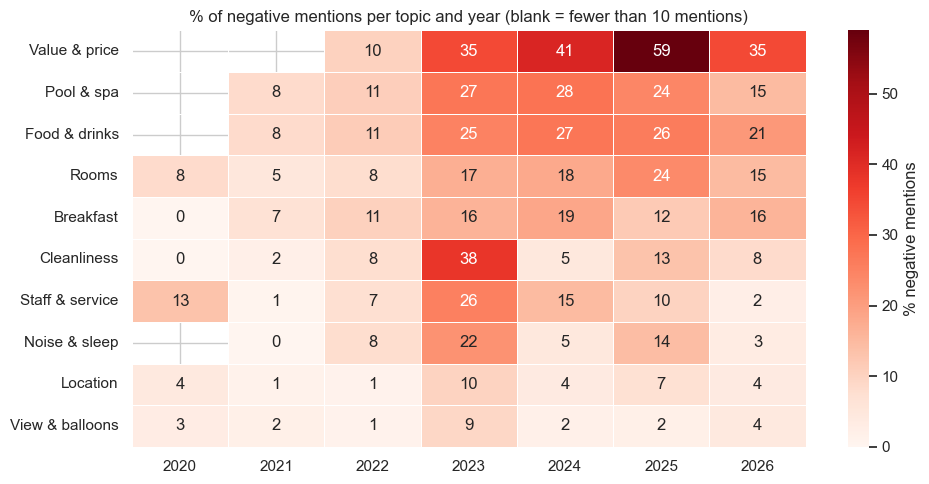

In [67]:
# % negative mentions per topic per year (cells with fewer than 10 mentions are left blank)
yearly_neg = mentions.pivot_table(index="topic", columns="year", values="sentence_label",
                                  aggfunc=lambda s: (s == "Negative").mean() * 100)
yearly_n = mentions.pivot_table(index="topic", columns="year", values="sentence", aggfunc="size")
yearly_neg = yearly_neg.where(yearly_n >= 10)

plt.figure(figsize=(10, 5))
sns.heatmap(yearly_neg.loc[topic_sentiment.index], annot=True, fmt=".0f", cmap="Reds",
            cbar_kws={"label": "% negative mentions"}, linewidths=0.5)
plt.xlabel("")
plt.ylabel("")
plt.title("% of negative mentions per topic and year (blank = fewer than 10 mentions)")
plt.tight_layout()
plt.show()

**What I see:**
- **Every topic became more negative after 2022**, which explains the rating drop found in Sections 6 and 7.
- The biggest change is **value & price**: negative mentions rose from **12% to 45%**, and the number of price mentions almost **tripled** (43 → 114). Guests increasingly feel the hotel is not worth the money.
- **Food & drinks (+16 pts)**, **pool & spa (+15 pts)**, **rooms (+12 pts)** and **cleanliness (+12 pts)** also worsened clearly.
- The **view and location barely changed**: the hotel's natural strengths are stable, and the decline comes from **operational** areas (pricing and extra charges, food, pool, room upkeep).

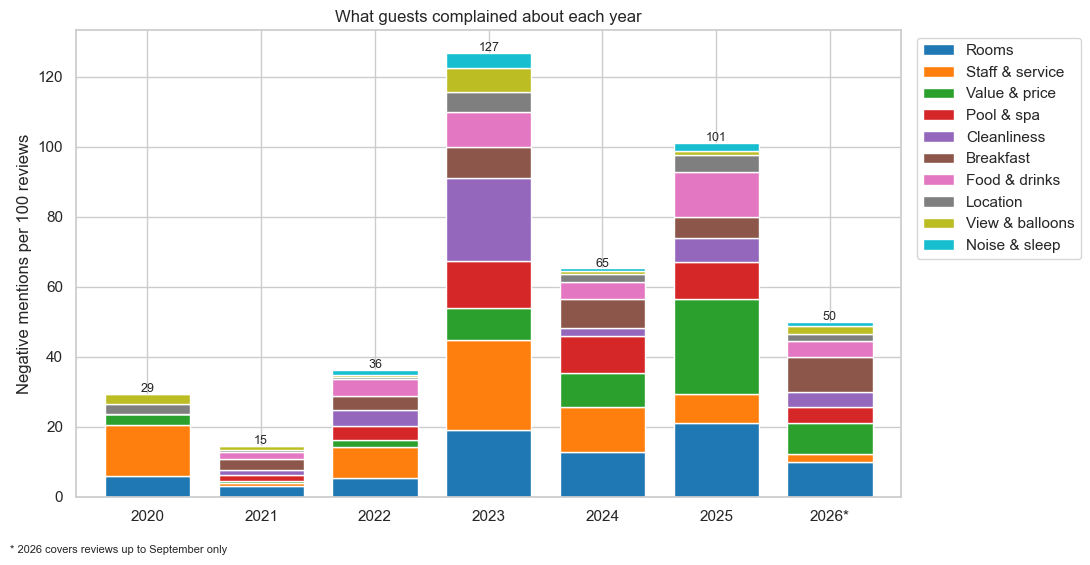

In [68]:
# Complaints per topic and year, per 100 reviews with text (adjusts for different review volumes)
neg_mentions = mentions[mentions["sentence_label"] == "Negative"]
reviews_per_year = sentences.groupby("year")["review_index"].nunique()

complaints = (neg_mentions.pivot_table(index="year", columns="topic", values="sentence",
                                       aggfunc="size", fill_value=0)
              .div(reviews_per_year, axis=0).mul(100))
complaints = complaints[complaints.sum().sort_values(ascending=False).index]   # biggest topics at the bottom

ax = complaints.plot(kind="bar", stacked=True, figsize=(11, 5.5), colormap="tab10", width=0.75)
ax.set_xlabel("")
ax.set_ylabel("Negative mentions per 100 reviews")
ax.set_title("What guests complained about each year")
ax.set_xticklabels([f"{y}*" if y == 2026 else str(y) for y in complaints.index], rotation=0)
ax.legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left")

# Total on top of each bar
for x, total in enumerate(complaints.sum(axis=1)):
    ax.text(x, total + 0.5, f"{total:.0f}", ha="center", fontsize=9)

plt.figtext(0.01, -0.02, "* 2026 covers reviews up to September only", fontsize=8)
plt.tight_layout()
plt.show()

**What I see:**
- Complaints rose sharply after 2022: from 15 per 100 reviews in 2021 to a peak of 127 in 2023, and they stayed high in 2025 (101).
- The type of complaint changed: in 2023, complaints were spread across staff & service, cleanliness, rooms and pool & spa; by 2025, value & price was the largest single source of complaints.
- Rooms complaints grew steadily and remained one of the biggest categories from 2023 onwards.
2026 shows fewer complaints (50 per 100 reviews), but it only covers reviews up to September.
- The 2020 figure is based on only 39 reviews, so it should be read with caution.

### 8.6 Priority matrix
To decide what the hotel should focus on, I combine how often a topic is mentioned with how negative those mentions are. The dashed lines are the medians:
- **Top right (fix first):** often mentioned and often negative
- **Bottom right (strengths):** often mentioned and rarely negative, worth promoting
- **Top left (watch):** rarely mentioned, but negative when it is

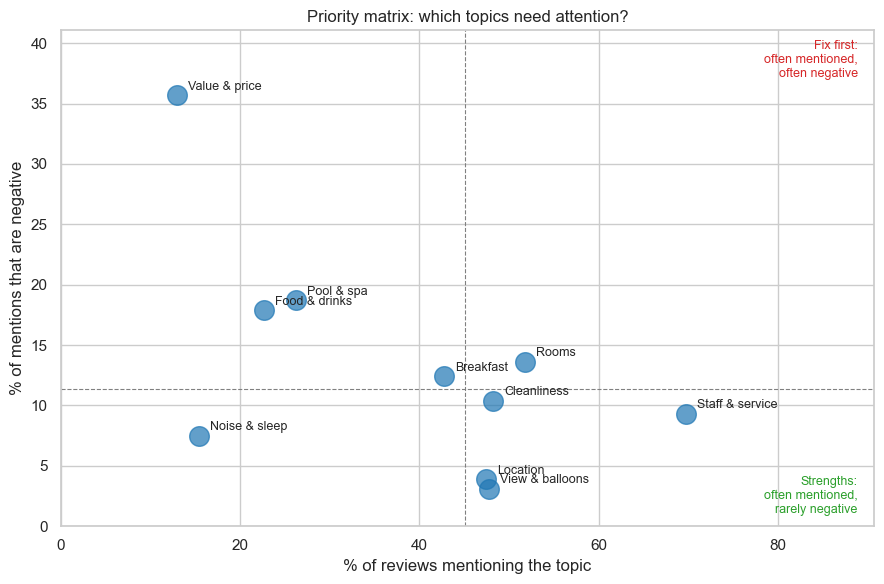

In [69]:
# Priority matrix: how often a topic is mentioned vs how negative those mentions are
matrix = pd.DataFrame({
    "reach": topic_reach,
    "pct_negative": topic_sentiment["pct_negative"],
})

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(matrix["reach"], matrix["pct_negative"], s=200, color="#1f77b4", alpha=0.7)
for topic, row in matrix.iterrows():
    ax.annotate(topic, (row["reach"], row["pct_negative"]), textcoords="offset points",
                xytext=(8, 4), fontsize=9)

# Median lines split the chart into four quadrants
ax.axvline(matrix["reach"].median(), color="grey", linestyle="--", linewidth=0.8)
ax.axhline(matrix["pct_negative"].median(), color="grey", linestyle="--", linewidth=0.8)
ax.text(0.98, 0.98, "Fix first:\noften mentioned,\noften negative", transform=ax.transAxes,
        ha="right", va="top", fontsize=9, color="#d62728")
ax.text(0.98, 0.02, "Strengths:\noften mentioned,\nrarely negative", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, color="#2ca02c")
ax.set_xlim(0, matrix["reach"].max() * 1.3)          # room on the right for labels
ax.set_ylim(0, matrix["pct_negative"].max() * 1.15)
ax.set_xlabel("% of reviews mentioning the topic")
ax.set_ylabel("% of mentions that are negative")
ax.set_title("Priority matrix: which topics need attention?")
plt.tight_layout()
plt.show()

**What I see:**
- **Fix first (often mentioned, often negative):** **rooms**. They are discussed in half of all reviews and complaints are rising.
- **Watch (less often mentioned, but often negative):** **value & price, pool & spa, food & drinks and breakfast**. Each is a clear source of frustration when it comes up.
- **Strengths (often mentioned, rarely negative):** **staff & service, cleanliness, view & balloons and location**. These should be highlighted in the hotel's marketing and protected, because staff and cleanliness problems cost the most stars when they occur (8.4).

### 8.7 What exactly do guests complain about?
Numbers show where the problems are; the sentences show what they are. Here I read the three most negative sentences for each of the five most criticised topics, which will make the recommendations in Section 9 concrete.

In [70]:
# The three most negative sentences for each of the five most criticised topics
top_complaints = topic_sentiment.head(5).index
(mentions[mentions["topic"].isin(top_complaints) & (mentions["sentence_label"] == "Negative")]
    .sort_values("negative", ascending=False)
    .groupby("topic").head(3)
    .sort_values(["topic", "negative"], ascending=[True, False])
    [["topic", "source", "year", "rating_5", "sentence"]])

,topic,source,year,rating_5,sentence
3822,Breakfast,Trip.com,2023,1.0,The breakfast was really bad.
2651,Breakfast,Expedia,2023,1.0,They called and said that their breakfast was very bad.
313,Breakfast,Google,2026,1.0,"They put the same breakfast on the table for two days in a row; the cheese smelled bad, and there was almost no variety."
6589,Food & drinks,Expedia,2022,4.0,The most disappointing part is the restaurant.
6701,Food & drinks,Tripadvisor,2025,1.0,"Bad service bad food, they offer ""spa services"" this is not true they hire 3rd party to come to hotel, then make u pay cash."
6303,Food & drinks,Booking,2024,1.5,"The hotel restaurant's food is not very good, and one day there's no cook."
29897,Pool & spa,Tripadvisor,2025,1.0,"Bad service bad food, they offer ""spa services"" this is not true they hire 3rd party to come to hotel, then make u pay cash."
27545,Pool & spa,Google,2025,1.0,"Bad service, bad food, they have “spa service” but then hire other company to come give massage then tell you to pay cash, if not they charge you 25% extra"
27810,Pool & spa,Google,2024,1.0,"The sauna looked unappealing, and a fee of 10 euros was charged per session."
21681,Rooms,Booking,2026,3.5,The sewer smell in the bathroom was absolutely nasty!!


**What I see:**
The complaints are specific and actionable:
- **Breakfast:** the same items served several days in a row, little variety, and cheese that was not fresh.
- **Food & drinks:** a disappointing restaurant, weak food quality, and days without a cook.
- **Pool & spa:** spa treatments run by an outside company that asks for cash payment or a 25% surcharge, and a €10 fee per sauna session.
- **Rooms:** a sewer smell in the bathroom, broken doors and shower heads, and hair in the bed.
- **Value & price:** guests say the stay was "not worth the money", often because of these extra charges.

(One guest posted a very similar complaint on both Google and Tripadvisor with slightly different wording, so it was not caught as a duplicate in Section 3 and appears twice here.)

### 8.8 What are the complaints about, exactly?
To make the recommendations precise, I split the negative sentences of the six most criticised topics into specific sub-issues, using a second, smaller keyword list per topic. "Other" collects complaints that don't match any sub-issue.

In [71]:
# Sub-issues inside the negative sentences of the most criticised topics
GENERAL = ["bad", "poor", "not good", "terrible", "awful", "disappoint", "average", "mediocre", "weak",
           "insufficient", "not enough", "inadequate", "not worth", "horrible", "worst", "unacceptable",
           "problem", "fell short", "expectation", "absurd", "let down", "leaves much to be desired",
           "basic", "simple", "ordinary", "standard", "5-star", "five-star", "expected", "nothing special", 
           "disturbing", "didn't like", "did not like", "uninteresting", "only ok", "meager", "meagre"]

SUB_ISSUES = {
    "Value & price": {
        "Paid water": ["water"],
        "Spa / sauna / massage fees": ["sauna", r"spa\b", "massage", "hamam", "hammam"],
        "Minibar": ["minibar"],
        "Foreign currency / payment method": ["euro", "currency", "lira", "dollar", "gbp", "pound", "cash",
                                              "card", "exchange", "contactless", "payment", "on site"],
        "Hidden or extra charges": ["extra", "additional", "charg", "fee", "not included", "included", "free",
                                    "bill", "commission", "percent", "%", "service charge"],
        "Felt cheated / payment disputes": ["conned", "scam", "cheat", "deceiv", "blackmail", "dispute",
                                            "receipt", "insist", "forced", "refund", "despite paying",
                                            "left the hotel", "damage"],
        "Price vs quality": ["expensive", "price", "worth", "value", "money", "overpriced", "cost", "per night",
                             "a night", r"tl\b", "£", "€", "compared to", "for the price", "at this price",
                             "half the price", "large amount", "rate"],
    },
    "Pool & spa": {
        "Cold / temperature": ["cold", "heat", "warm", "temperature", "freezing"],
        "Small": ["small", "tiny"],
        "Extra fees": ["fee", "pay", "paid", "charg", "euro", "cash", "extra"],
        "Outsourced spa / massage": ["massage", "third", "3rd", "company", "outside"],
        "Indoor / outdoor pool use": ["indoor", "outdoor", "open", "use", "water"],
        "Pool area & facilities": ["sunbed", "lounger", "chair", "umbrella", "shade", "towel", "crowd",
                                   "children", "kids", "area", "terrace"],
        "Dirty / poorly maintained": ["dirt", "filth", "hygien", "clean", "leaves", "hair", "neglect",
                                      "kept", "care", "swept", "cloudy", "floating", "insect", "bee",
                                      "maintain", "health"],
        "Opening hours / closed": ["closed", "not open", "out of service", "out of use", "not in use",
                                   "not working", "unavailable", "season", "couldn't use", "could not use",
                                   "hours", "closes", "closing", "close by", "close too", "close early"],
        "Rules / restrictions": ["not allowed", "cancel", "bother", "rule", "music", "forbid"],
        "Noise / construction": ["construction", "noise", "drill", "build"],
        "Pool staff": ["staff", "understaff", "lifeguard"],
    },
    "Food & drinks": {
        "Slow service": ["slow", "wait", "minutes", "late", "took"],
        "Food quality": ["taste", "tasteless", "quality", "cold", "fresh", "raw", "overcooked", "salty"],
        "Limited menu / no cook": ["menu", "cook", "chef", "variety", "option", "choice", "limited"],
        "Price": ["expensive", "price", "cost", "overpriced"],
        "Drinks / bar": [r"bar\b", "drink", "alcohol", "wine", "beer", "cocktail", "coffee", r"tea\b"],
        "General dissatisfaction": GENERAL,
    },
    "Rooms": {
        "Bathroom & smell": ["bathroom", "shower", "toilet", "smell", "sewer", "drain", "odour", "odor", "smok"],
        "Broken / maintenance": ["broken", "faulty", "repair", "fix", "not working", "old", "worn", "leak",
                                 "damaged", "door", "lock", "flicker"],
        "Bed / room size": [r"bed", "small", "narrow", "pillow", "mattress", "cramped", "tiny", "bigger"],
        "Dirty": ["dirt", "hair", "clean", "dust", "stain", "insect", "bug", "cobweb"],
        "Noise": ["noise", "noisy", "soundproof", "hear", "loud", "thin wall"],
        "Heating / cooling": ["cold", "heat", "air condition", r"ac\b", "warm", "temperature", "air"],
        "Amenities (Wi-Fi, TV, kettle)": ["wifi", "wi-fi", "internet", r"tv\b", "television", "kettle",
                                          "toothpaste", "slipper", "amenit", "towel"],
        "Not as booked / advertised": ["advertis", "picture", "photo", "booked", "reservation", "assign",
                                       "view", "catalog", "available", "change room", "ground floor",
                                       "room number", "random", "upgrade"],
        "Light / darkness": ["dark", "light", "sunlight", "bright", "curtain", "blackout", "window"],
        "Missing furniture": ["wardrobe", "closet", "mirror", "furniture", "luggage", "shelf"],
        "Charges in the room": ["water", "room card", "extra", "charg"],
        "Accessibility": ["wheelchair", "weelchair", "walker", "accessib", "stairs"],
        "General dissatisfaction": GENERAL,
    },
    "Breakfast": {
        "Quality / freshness": ["fresh", "smell", "cold", "quality", "taste", "stale", "tasteless"],
        "Service / refilling": ["refill", "empty", "wait", "slow", "run out", "ran out", "replenish"],
        "Hot dishes / cooked food": ["hot", "dish", "cooked", "omelet", "omelette", "pastry", "portion"],
        "Specific items": ["egg", "bread", "cheese", "olive", "coffee", r"tea\b", "juice", "fruit", "meat"],
        "Little variety": ["variety", "same", "choice", "option", "limited", "repetit", "monoton", "few",
                           "every day", "rich", "set", "meager", "meagre", "anything to eat", "nothing to eat"],
        "Times / organisation": ["time", "hour", "early", "late", "crowd", "table", "seat", "served",
                                 "ready", "cancel", "call"],
        "Specific items": ["egg", "bread", "cheese", "olive", "coffee", r"tea\b", "juice", "fruit", "meat",
                           "salami", "sausage"],
        "General dissatisfaction": GENERAL,
    },
    "Staff & service": {
        "Language / communication": ["english", "language", "speak", "understand", "inform", "information"],
        "Slow / unresponsive": ["slow", "wait", "late", "respon", "no one", "nobody", "ignored", "never came",
                                "didn't come", "did not come", "long time", "minutes", "couldn't find"],
        "Attitude": ["rude", "attitude", "unfriendly", "impolite", "angry", "grouch", "grumpy", "irritable",
                     "unhelpful", "helpful", "careless", "cares little", "indifferent", "disrespect", "smile",
                     "shout", "yell", "warn", "lazy", "argument", "friendl", "enthusias", "welcome", "greet",
                     "cheerful", "face", "attention"],
        "Unprofessional / inexperienced": ["professional", "trainee", "inexperienc", "young", "manag",
                                           "training", "threat", "blackmail", "slander", "sly",
                                           "incompetent", "children", "sleeping"],
        "Housekeeping": ["cleaning staff", "clean", "swept", "restock", "housekeep", "tidy", "messy", "bins"],
        "Staff smoking": ["smok"],
        "Payment handling": ["gbp", "insist", "charge", "pay", "cash"],
        "Staff shortage": ["shortage", "understaff", "not enough staff", "only one", "small number",
                           "few staff", "tired", "bellboy"],
        "Selling tours": ["tour", "sell", "package", "agenc", "excursion"],
        "Check-in / reservation": ["check-in", "check in", "checkin", "check-out", "check out", "checkout",
                                   "reservation", "booking", "booked", "room change", "upgrade"],
        "General dissatisfaction": GENERAL + ["much better", "better service", "better places", "elsewhere",
                                              "somewhere else", "somewhere more", "different hotel"],
    },
}

rows = []
for topic, issues in SUB_ISSUES.items():
    neg = mentions[(mentions["topic"] == topic) & (mentions["sentence_label"] == "Negative")]
    matched_any = pd.Series(False, index=neg.index)
    for issue, words in issues.items():
        pattern = re.compile(r"\b(?:" + "|".join(words) + ")", re.IGNORECASE)
        hit = neg["sentence"].map(lambda s: bool(pattern.search(str(s))))
        matched_any |= hit
        rows.append({"topic": topic, "issue": issue, "sentences": hit.sum(),
                     "pct_of_topic_complaints": hit.mean() * 100})
    rows.append({"topic": topic, "issue": "Other", "sentences": (~matched_any).sum(),
                 "pct_of_topic_complaints": (~matched_any).mean() * 100})

# A sentence can match several sub-issues, so percentages can add up to more than 100%
sub_issues = pd.DataFrame(rows).round(1)
(sub_issues[sub_issues["sentences"] > 0]
    .assign(is_other=lambda d: d["issue"] == "Other")
    .sort_values(["topic", "is_other", "sentences"], ascending=[True, True, False])
    .drop(columns="is_other"))

,topic,issue,sentences,pct_of_topic_complaints
47,Breakfast,General dissatisfaction,30,69.8
45,Breakfast,Little variety,8,18.6
46,Breakfast,Times / organisation,7,16.3
43,Breakfast,Hot dishes / cooked food,6,14.0
41,Breakfast,Quality / freshness,4,9.3
44,Breakfast,Specific items,4,9.3
42,Breakfast,Service / refilling,1,2.3
48,Breakfast,Other,3,7.0
25,Food & drinks,General dissatisfaction,17,42.5
24,Food & drinks,Drinks / bar,14,35.0


In [72]:
# Complaints that still don't match any sub-issue, for topics where "Other" is above 30%
def matches_any(sentence, issues):
    return any(re.search(r"\b(?:" + "|".join(words) + ")", str(sentence), re.IGNORECASE)
               for words in issues.values())

high_other = sub_issues[(sub_issues["issue"] == "Other") & (sub_issues["pct_of_topic_complaints"] > 30)]["topic"]
leftovers = []
for topic in high_other:
    neg = mentions[(mentions["topic"] == topic) & (mentions["sentence_label"] == "Negative")]
    left = neg[~neg["sentence"].map(lambda s: matches_any(s, SUB_ISSUES[topic]))]
    leftovers.append(left[["topic", "year", "rating_5", "sentence"]])

leftovers = pd.concat(leftovers) if leftovers else pd.DataFrame()
leftovers.to_csv(os.path.join(DATA_DIR, "other_leftovers.csv"), index=False, encoding="utf-8-sig")
print(leftovers["topic"].value_counts() if len(leftovers) else "All topics are at 30% or below")
leftovers

All topics are at 30% or below


""


In [73]:
# Complaints that still don't match any sub-issue: read them to spot missing keywords
def matches_any(sentence, issues):
    return any(re.search(r"\b(?:" + "|".join(words) + ")", str(sentence), re.IGNORECASE)
               for words in issues.values())

TOPIC_TO_CHECK = "Staff & service"   # change to check another topic
neg = mentions[(mentions["topic"] == TOPIC_TO_CHECK) & (mentions["sentence_label"] == "Negative")]
neg[~neg["sentence"].map(lambda s: matches_any(s, SUB_ISSUES[TOPIC_TO_CHECK]))][["year", "rating_5", "sentence"]]

,year,rating_5,sentence
15866,2025,4.0,"- As a guest from an expensive city like Bodrum, I have to say that the spa and Turkish bath are unnecessarily expensive and don't offer a very special service in this area."
16279,2024,4.0,"There are a few things which let this hotel down, breakfast, hospitality and some missing room essentials."
16916,2022,4.0,This goes against the logic of good service.
18075,2024,3.0,"The hotel's rooms and breakfast are good, but the balloon-watching terrace is unfortunately under the care of the pool and the staff."
19080,2020,3.0,"The hotel design is great, but the staff don't even know how to talk crap."
19083,2020,3.0,I would never recommend it because of personnel.


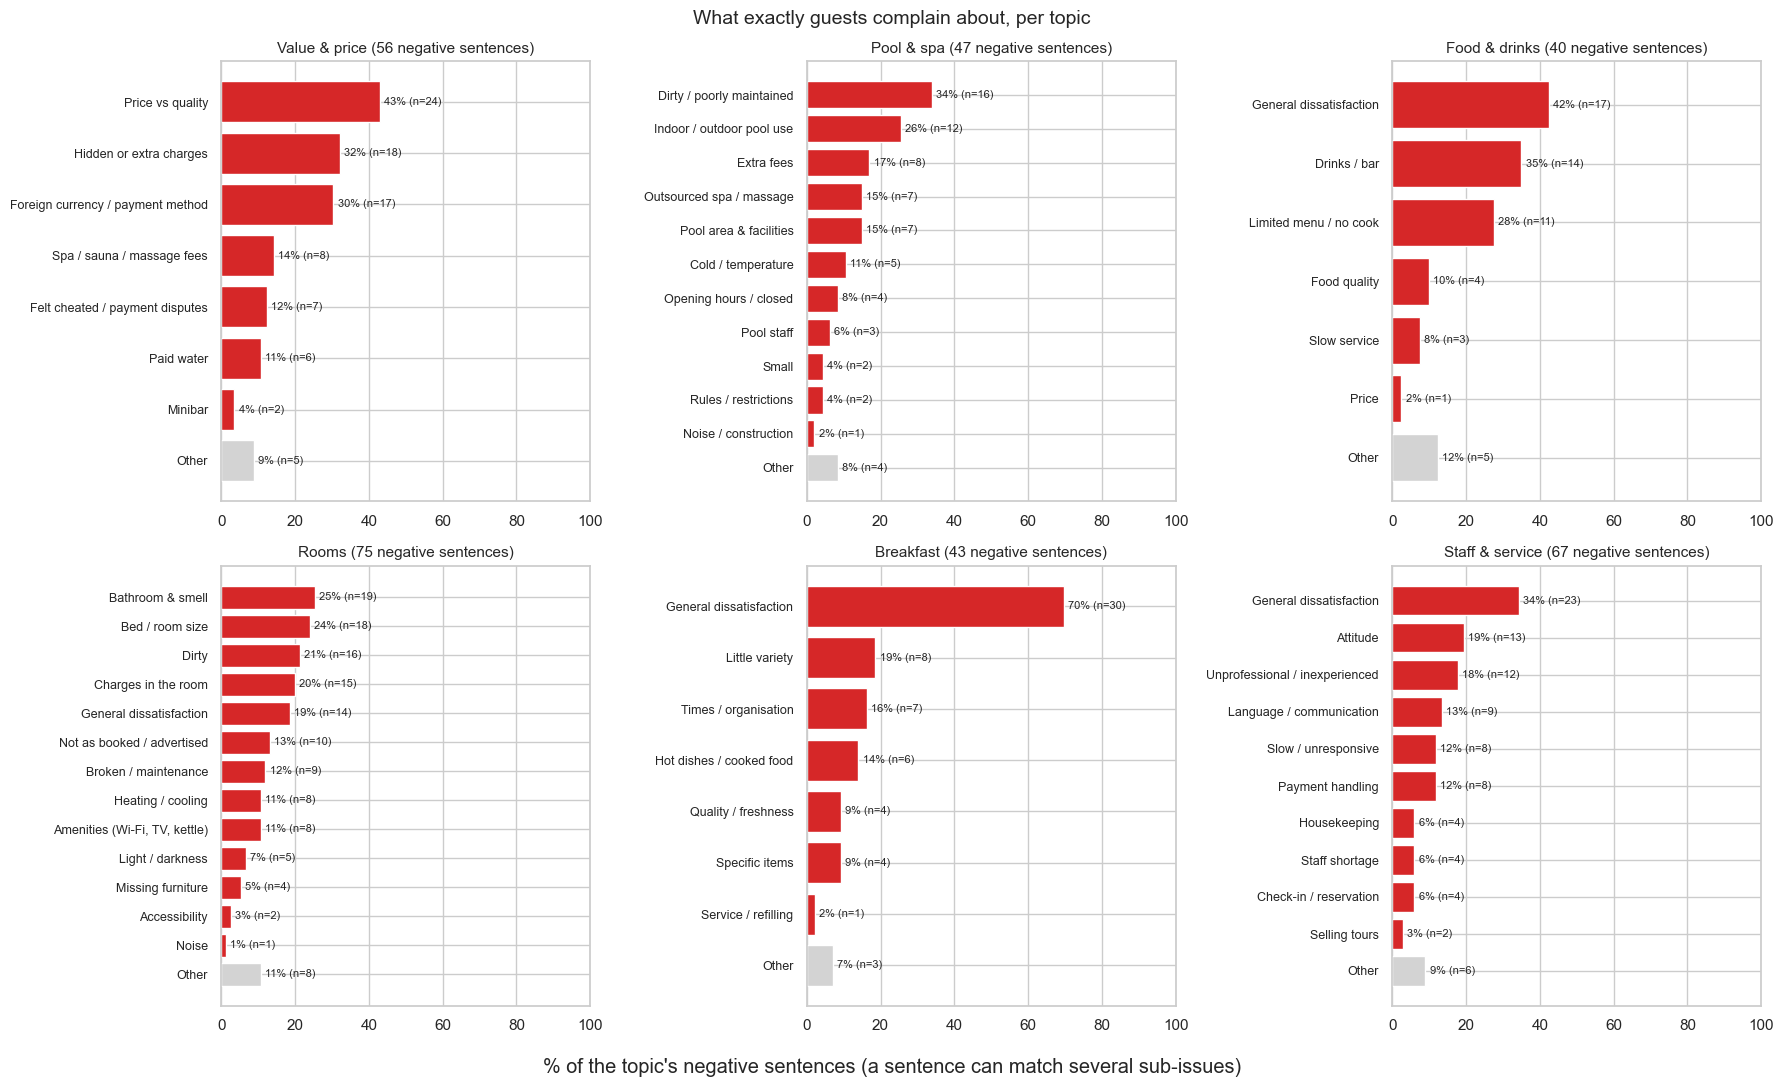

In [74]:
# One small bar chart per topic: share of that topic's complaints per sub-issue ("Other" in grey)
topics_to_plot = list(SUB_ISSUES)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, topic in zip(axes.flat, topics_to_plot):
    data = sub_issues[(sub_issues["topic"] == topic) & (sub_issues["sentences"] > 0)]
    data = pd.concat([data[data["issue"] != "Other"].sort_values("pct_of_topic_complaints", ascending=False),
                      data[data["issue"] == "Other"]])          # "Other" always at the bottom
    colours = ["lightgrey" if i == "Other" else GROUP_COLOURS["Negative"] for i in data["issue"]]
    ax.barh(data["issue"], data["pct_of_topic_complaints"], color=colours)
    ax.bar_label(ax.containers[0], labels=[f"{p:.0f}% (n={n})" for p, n in
                 zip(data["pct_of_topic_complaints"], data["sentences"])], padding=3, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    n_complaints = ((mentions["topic"] == topic) & (mentions["sentence_label"] == "Negative")).sum()
    ax.set_title(f"{topic} ({n_complaints} negative sentences)", fontsize=11)
    ax.tick_params(axis="y", labelsize=9)

fig.supxlabel("% of the topic's negative sentences (a sentence can match several sub-issues)")
fig.suptitle("What exactly guests complain about, per topic", fontsize=14)
plt.tight_layout()
plt.show()

**What I see:**
- After refining the keywords, only **7-12% of complaints per topic** remain in "Other", so the sub-issues describe almost all complaints.
- **Value & price:** the biggest issue is that the stay does not feel **worth the price (43%)**, driven by **hidden or extra charges (32%)** and **payment practices (30%)**: being asked to pay in euros or GBP instead of lira, cash-only payments, a hidden 10% service charge, and receipts stating the guest had "chosen" the foreign currency. Spa/sauna fees (14%) and paid water (11%) add to this, and **12%** of price complaints describe guests feeling **cheated**.
- **Pool & spa:** the main problem is **poor maintenance (34%)**: cloudy water, not swept, insects. Next come **not being able to use the indoor/outdoor pool (26%)**, **extra fees (17%)** and the **outsourced spa/massage service (15%)**.
- **Food & drinks:** apart from general complaints (42%), guests criticise the **bar and drinks (35%)** and the **limited menu or no cook being available (28%)** more than the taste of the food (10%).
- **Rooms:** complaints are spread across several issues: **bathroom and bad smells (25%)**, **small beds or rooms (24%)**, **dirt (21%)** and **charges in the room (20%)**, such as paid water and room card fees. **13%** say the room was **not as booked or advertised** (different floor, no promised view, smaller than in the photos).
- **Breakfast:** most complaints are general (70%, e.g. "poor", "not good"); the specific ones are about **little variety (19%)**, **timing and organisation (16%)** and **hot dishes (14%)**.
- **Staff & service:** besides general complaints (34%), guests mention **attitude (19%)**, **unprofessional or inexperienced staff and management (18%)**, **communication/language (13%)**, **slow responses (12%)** and **payment handling (12%)**.

### 8.9 Do Turkish and foreign guests complain about different things?
In 6.4, guests writing in languages other than Turkish or English were less satisfied. Here I check whether the three language groups are unhappy about the same topics. Cells with fewer than 15 mentions are left blank.

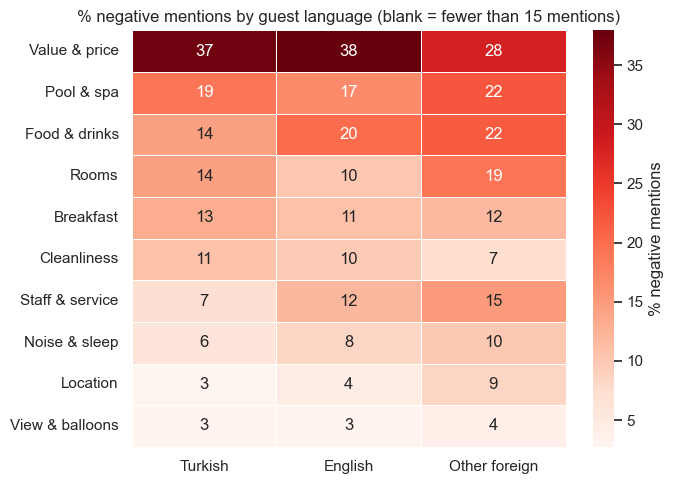

In [75]:
# Language group of each review (same groups as Section 6.4), added to every mention
def language_group(lang):
    if pd.isna(lang):
        return "No text"
    return {"tr": "Turkish", "en": "English"}.get(lang, "Other foreign")

mentions["guest_group"] = mentions["review_index"].map(reviews["language"].map(language_group))

group_neg = mentions.pivot_table(index="topic", columns="guest_group", values="sentence_label",
                                 aggfunc=lambda s: (s == "Negative").mean() * 100)
group_n = mentions.pivot_table(index="topic", columns="guest_group", values="sentence", aggfunc="size")
group_neg = group_neg.where(group_n >= 15)[["Turkish", "English", "Other foreign"]]

plt.figure(figsize=(7, 5))
sns.heatmap(group_neg.loc[topic_sentiment.index], annot=True, fmt=".0f", cmap="Reds",
            cbar_kws={"label": "% negative mentions"}, linewidths=0.5)
plt.xlabel("")
plt.ylabel("")
plt.title("% negative mentions by guest language (blank = fewer than 15 mentions)")
plt.tight_layout()
plt.show()

**What I see:**
- **Value & price** is the top complaint for every group, but it is most negative among **Turkish (37%) and English-speaking (38%)** guests.
- Guests writing in **other languages** are more critical of **rooms (19%)**, **staff & service (15%)**, food & drinks (22%) and location (9%). Staff complaints from this group are about twice as common as from Turkish guests (7%), which fits with the language and communication problems mentioned in the reviews.
- **English-speaking guests** are the most critical of **food & drinks (20%)**.

### 8.10 Which topics cause problems in which season?
In 6.3, spring had the lowest satisfaction. Here I check which topics are behind this, e.g. whether the pool is more often criticised outside summer.

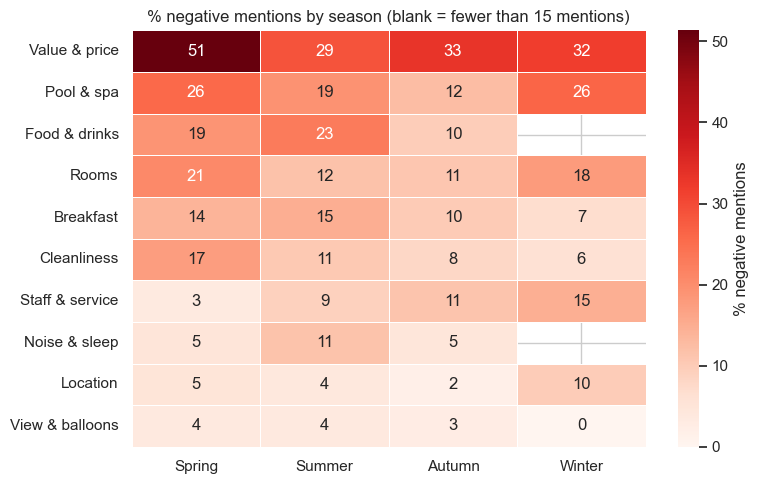

In [76]:
# Season of each review, added to every mention (SEASONS comes from Section 6.0)
review_month = pd.to_datetime(reviews["review_date"], utc=True, format="mixed").dt.month
mentions["season"] = mentions["review_index"].map(review_month.map(SEASONS))

season_neg = mentions.pivot_table(index="topic", columns="season", values="sentence_label",
                                  aggfunc=lambda s: (s == "Negative").mean() * 100)
season_n = mentions.pivot_table(index="topic", columns="season", values="sentence", aggfunc="size")
season_neg = season_neg.where(season_n >= 15)[["Spring", "Summer", "Autumn", "Winter"]]

plt.figure(figsize=(8, 5))
sns.heatmap(season_neg.loc[topic_sentiment.index], annot=True, fmt=".0f", cmap="Reds",
            cbar_kws={"label": "% negative mentions"}, linewidths=0.5)
plt.xlabel("")
plt.ylabel("")
plt.title("% negative mentions by season (blank = fewer than 15 mentions)")
plt.tight_layout()
plt.show()

**What I see:**
- **Spring is the worst season for value & price (51% negative)**, rooms (21%) and cleanliness (17%), which explains the lower spring ratings found in 6.3.
- **Pool & spa** complaints are highest in **spring and winter (26%)** and lowest in autumn (12%), which fits with the pools being cold or closed outside summer.
- **Staff & service** complaints rise steadily from spring (3%) to **winter (15%)**, possibly a sign of fewer staff in the low season.
- **Food & drinks** is most criticised in **summer (23%)**, when the hotel is busiest.

### 8.11 How did the specific complaints change over the years?
Here I track each sub-issue over time. Because the number of reviews differs a lot per year (e.g. 157 reviews with text in 2021 but 85 in 2025), I show both the **number of complaints** and the **rate per 100 reviews**, so years with fewer reviews can be compared fairly.

In [77]:
# One row per (negative sentence, sub-issue) match, keeping the year
issue_rows = []
for topic, issues in SUB_ISSUES.items():
    neg = mentions[(mentions["topic"] == topic) & (mentions["sentence_label"] == "Negative")]
    for issue, words in issues.items():
        pattern = re.compile(r"\b(?:" + "|".join(words) + ")", re.IGNORECASE)
        hit = neg[neg["sentence"].map(lambda s: bool(pattern.search(str(s))))]
        issue_rows.append(hit.assign(issue=issue)[["review_index", "year", "topic", "issue", "sentence"]])
issue_mentions = pd.concat(issue_rows, ignore_index=True)

# Number of reviews with text per year and per period, to turn counts into a rate per 100 reviews
reviews_per_year = sentences.groupby("year")["review_index"].nunique()
reviews_per_period = sentences.assign(
    period=np.where(sentences["year"] <= 2022, "2020-2022", "2023-2026")
).groupby("period")["review_index"].nunique()

print(len(issue_mentions), "sub-issue mentions")
reviews_per_year

475 sub-issue mentions


year
2020     34
2021    157
2022    149
2023     89
2024    124
2025     85
2026     90
Name: review_index, dtype: int64

In [78]:
# Counts and rate per 100 reviews, before vs after 2022
issue_mentions["period"] = np.where(issue_mentions["year"] <= 2022, "2020-2022", "2023-2026")
period_counts = issue_mentions.pivot_table(index=["topic", "issue"], columns="period",
                                           values="sentence", aggfunc="size", fill_value=0)
period_rate = period_counts.div(reviews_per_period, axis=1).mul(100).round(1)

issue_change = pd.concat({"count": period_counts, "per 100 reviews": period_rate}, axis=1)
issue_change[("per 100 reviews", "change")] = (
    issue_change[("per 100 reviews", "2023-2026")] - issue_change[("per 100 reviews", "2020-2022")]
)
issue_change.sort_values(("per 100 reviews", "change"), ascending=False)

count            \
period                                            2020-2022 2023-2026   
topic           issue                                                   
Value & price   Price vs quality                          1        23   
Staff & service General dissatisfaction                   3        20   
Value & price   Foreign currency / payment method         1        16   
Pool & spa      Dirty / poorly maintained                 1        15   
Value & price   Hidden or extra charges                   2        16   
Breakfast       General dissatisfaction                   8        22   
Rooms           Bathroom & smell                          3        16   
                Charges in the room                       2        13   
Food & drinks   Drinks / bar                              2        12   
Rooms           General dissatisfaction                   2        12   
                Dirty                                     3        13   
Food & drinks   General dissatisfaction                   4        13   
Breakfast       Little variety                            0         8   
Rooms           Bed / room size                           5        13   
                Broken / maintenance                      1         8   
Pool & spa      Outsourced spa / massage                  0         7   
Rooms           Heating / cooling                         1         7   
                Amenities (Wi-Fi, TV, kettle)             1         7   
Value & price   Paid water                                0         6   
Pool & spa      Indoor / outdoor pool use                 3         9   
                Cold / temperature                        0         5   
Food & drinks   Limited menu / no cook                    3         8   
Breakfast       Times / organisation                      1         6   
Pool & spa      Pool area & facilities                    1         6   
Value & price   Felt cheated / payment disputes           1         6   
Staff & service Staff shortage                            0         4   
                Check-in / reservation                    0         4   
Breakfast       Hot dishes / cooked food                  1         5   
Food & drinks   Food quality                              0         4   
Staff & service Slow / unresponsive                       2         6   
Pool & spa      Extra fees                                2         6   
Rooms           Not as booked / advertised                3         7   
Staff & service Payment handling                          2         6   
Value & price   Spa / sauna / massage fees                2         6   
Food & drinks   Slow service                              0         3   
Rooms           Light / darkness                          1         4   
Staff & service Attitude                                  5         8   
Pool & spa      Opening hours / closed                    1         3   
Breakfast       Quality / freshness                       1         3   
Value & price   Minibar                                   0         2   
Pool & spa      Rules / restrictions                      0         2   
Staff & service Housekeeping                              1         3   
Rooms           Accessibility                             0         2   
                Missing furniture                         1         3   
Pool & spa      Noise / construction                      0         1   
Food & drinks   Price                                     0         1   
Pool & spa      Pool staff                                1         2   
Staff & service Language / communication                  4         5   
Pool & spa      Small                                     1         1   
Staff & service Selling tours                             1         1   
Breakfast       Specific items                            2         2   
Rooms           Noise                                     1         0   
Breakfast       Service / refilling    

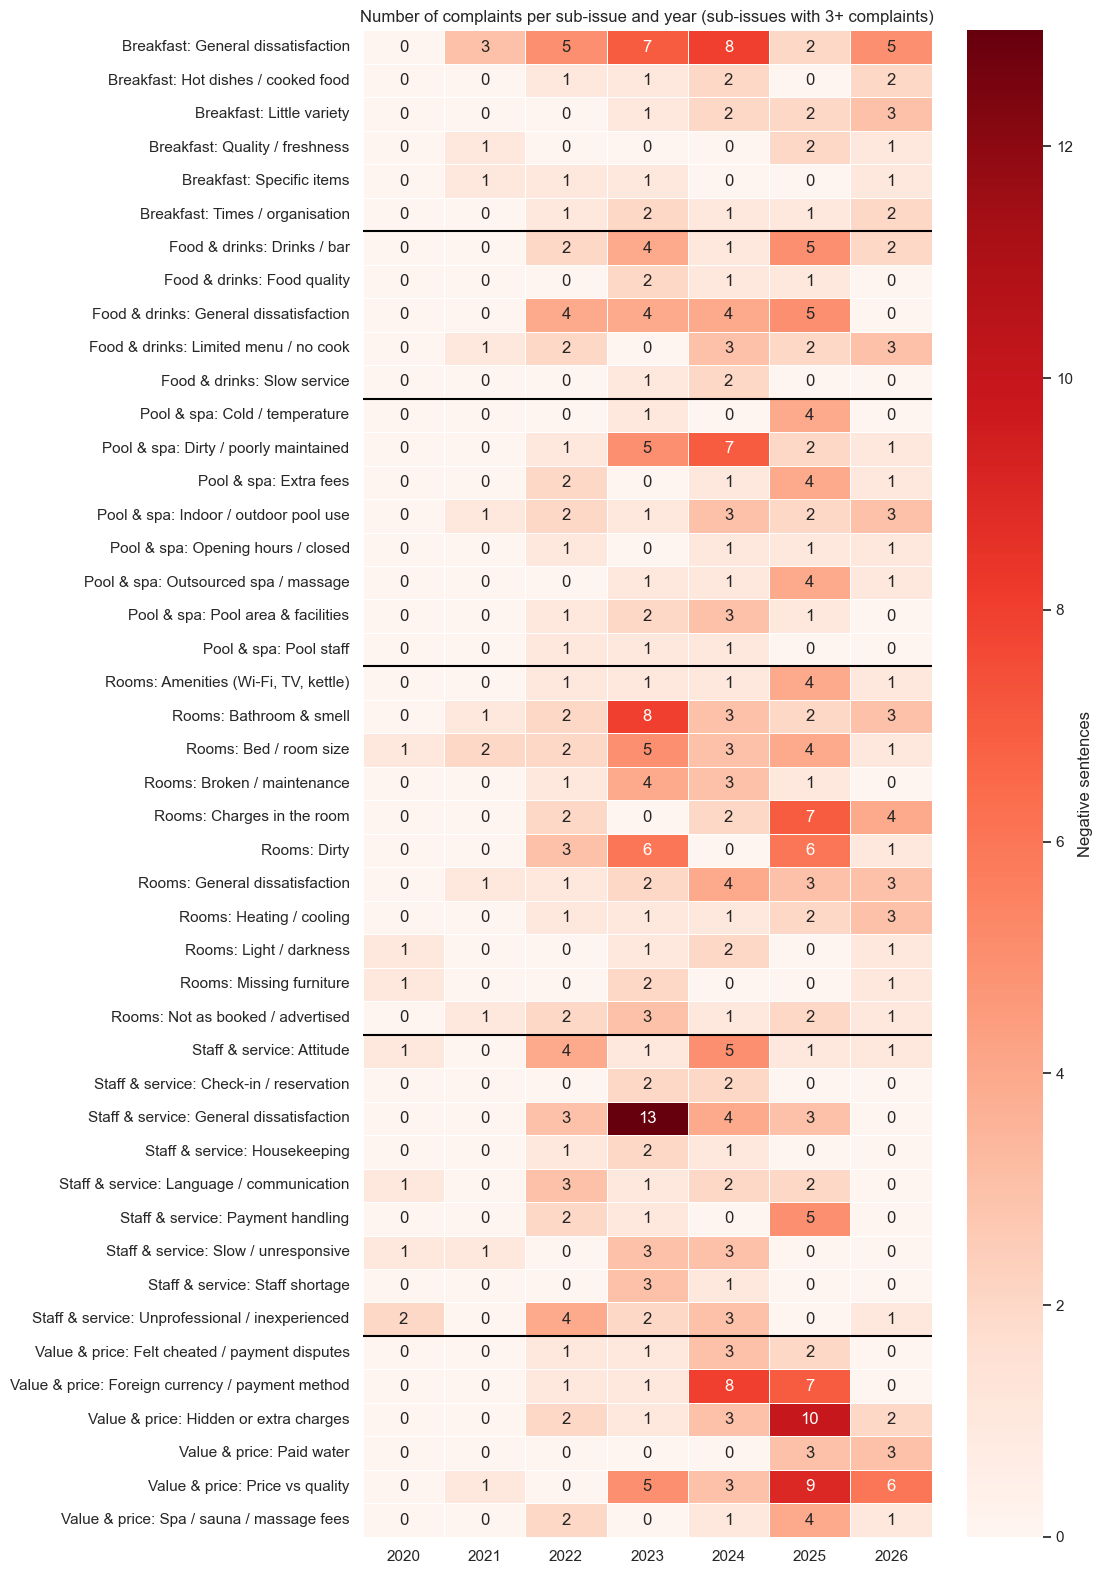

In [79]:
# Heatmap: number of negative sentences per sub-issue and year, grouped by topic
yearly_counts = issue_mentions.pivot_table(index=["topic", "issue"], columns="year",
                                           values="sentence", aggfunc="size", fill_value=0)
yearly_counts = yearly_counts[yearly_counts.sum(axis=1) >= 3]         # hide very rare sub-issues
yearly_counts.index = [f"{t}: {i}" for t, i in yearly_counts.index]

plt.figure(figsize=(11, 0.32 * len(yearly_counts) + 1.5))
ax = sns.heatmap(yearly_counts, annot=True, fmt="d", cmap="Reds", linewidths=0.5,
                 cbar_kws={"label": "Negative sentences"})
# Black lines between topics
topics_in_order = [label.split(":")[0] for label in yearly_counts.index]
for y in range(1, len(topics_in_order)):
    if topics_in_order[y] != topics_in_order[y - 1]:
        ax.axhline(y, color="black", linewidth=1.5)
plt.xlabel("")
plt.ylabel("")
plt.title("Number of complaints per sub-issue and year (sub-issues with 3+ complaints)")
plt.tight_layout()
plt.show()

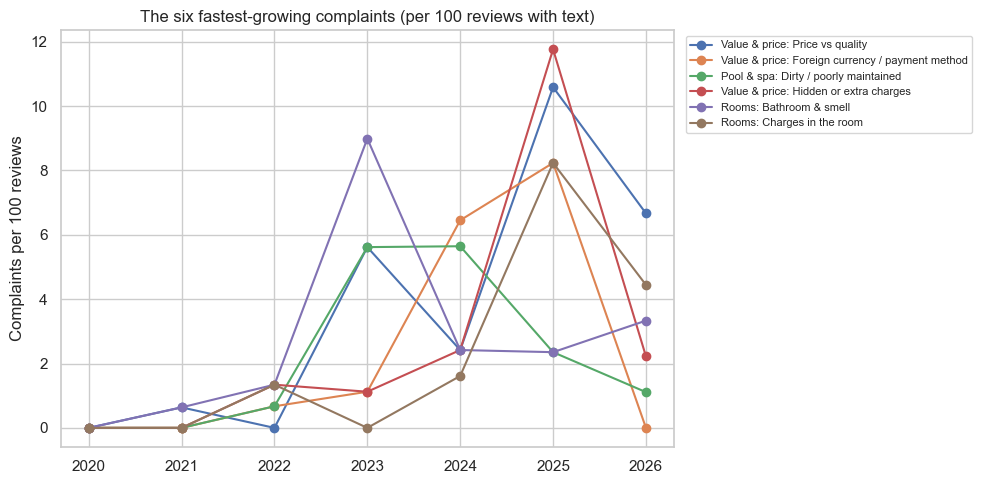

In [80]:
# The six sub-issues that grew the most: complaints per 100 reviews, per year
top_growth = (issue_change[("per 100 reviews", "change")]
              .drop(index=[i for i in issue_change.index if i[1] in ("Other", "General dissatisfaction")])
              .nlargest(6).index)

rates = issue_mentions.pivot_table(index=["topic", "issue"], columns="year",
                                   values="sentence", aggfunc="size", fill_value=0)
rates = rates.loc[top_growth].div(reviews_per_year, axis=1).mul(100)

fig, ax = plt.subplots(figsize=(10, 5))
for (topic, issue), row in rates.iterrows():
    ax.plot(row.index, row.values, marker="o", label=f"{topic}: {issue}")
ax.set_ylabel("Complaints per 100 reviews")
ax.set_xlabel("")
ax.set_title("The six fastest-growing complaints (per 100 reviews with text)")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

**What I see:**
- **Value & price complaints grew the most**: "not worth the price" went from **1 complaint (0.3 per 100 reviews) in 2020-2022 to 23 (5.9 per 100) in 2023-2026**. Complaints about **foreign-currency payment** (0.3 → 4.1), **hidden or extra charges** (0.6 → 4.1), **charges in the room** (0.6 → 3.4) and **paid water** (0 → 1.5) rose at the same time. Together they show that **pricing and payment practices** changed after 2022.
- These charge-related complaints **peaked in 2025** (e.g. 11.8 hidden-charge complaints per 100 reviews) and dropped in 2026 (foreign-currency complaints fell to zero), which may mean the hotel has started to change these practices. 2026 only covers reviews up to September, so this needs to be confirmed.
- **Pool maintenance** complaints (0.3 → 3.9 per 100) peaked in **2023-2024** and have been falling since, and **bathroom and smell** complaints spiked in **2023** (9 per 100).
- Several issues **only appeared after 2022**: little breakfast variety, the outsourced spa, paid water, check-in problems and staff shortage.
- Staff complaints about **communication, professionalism and attitude stayed roughly the same** over time, so they are a long-standing weakness rather than a new one.

### 8.12 Save the results
I save the tagged sentences and a one-table summary per topic (reach, sentiment, rating impact and change over time), which I use for the recommendations in Section 9.

In [81]:
sub_issues.to_csv(os.path.join(DATA_DIR, "topic_sub_issues.csv"), index=False, encoding="utf-8-sig")
issue_change.to_csv(os.path.join(DATA_DIR, "sub_issues_over_time.csv"), encoding="utf-8-sig")
sentences.to_csv(os.path.join(DATA_DIR, "sentences_topics.csv"), index=False, encoding="utf-8-sig")

topic_summary = topic_sentiment.join(topic_reach.rename("pct_reviews_mentioning").round(1)) \
    .join(impact["rating_gap"].round(2)).join(period_neg["change_pts"])
topic_summary.to_csv(os.path.join(DATA_DIR, "topic_summary.csv"), encoding="utf-8-sig")
topic_summary

,mentions,pct_positive,pct_neutral,pct_negative,avg_score,pct_reviews_mentioning,rating_gap,change_pts
topic,,,,,,,,
Value & price,157,27.4,36.9,35.7,-0.1,12.9,2.01,33.1
Pool & spa,251,57.4,23.9,18.7,0.4,26.2,1.61,15.1
Food & drinks,224,65.2,17.0,17.9,0.5,22.7,1.88,15.7
Rooms,552,64.3,22.1,13.6,0.5,51.8,1.72,11.8
Breakfast,346,78.9,8.7,12.4,0.6,42.7,1.92,8.3
Cleanliness,413,84.5,5.1,10.4,0.7,48.2,2.15,11.5
Staff & service,718,82.0,8.6,9.3,0.7,69.8,2.27,8.4
Noise & sleep,133,74.4,18.0,7.5,0.6,15.4,1.28,5.6
Location,437,73.0,23.1,3.9,0.7,47.4,1.75,4.5


## 9. Findings & Recommendations

### 9.1 Key findings
1. **Guests are very satisfied overall, but satisfaction has dropped.** The average rating is **4.62 / 5** across 919 unique reviews, but it fell significantly from **4.84 (2020-2022) to 4.45 (2023-2026)** (Mann-Whitney U, p < 0.001), and negative reviews rose from about 0-2% to about 10%. The drop appears on every platform, and the review texts confirm it (Section 7).
2. **The hotel's core strengths are stable.** The **view and balloons (3% negative)** and **location (4%)** are rarely criticised and barely changed over time, and staff and cleanliness are praised in more than 80% of mentions.
3. **The drop comes from operational issues, mainly pricing.** **Value & price** became the most negative topic (negative mentions rose from **12% to 45%**), driven by **hidden and extra charges** (water, sauna, spa, a 10% service charge) and **payment practices** (paying in euros/GBP instead of lira, cash-only). Reviews with a price complaint average only **2.38 stars**.
4. **Rooms, pool and food also worsened.** Rooms are the only topic in the "fix first" quadrant (mentioned in 52% of reviews, 14% negative), mainly because of **bathroom smells, small beds, dirt and charges in the room**. Pool & spa (+15 points negative) suffers from **poor maintenance and limited use outside summer**, and food & drinks (+16 points) from a **limited menu, no cook at times and the bar**.
5. **Staff problems cost the most stars.** Although staff are usually praised, a staff complaint lowers the rating by **2.3 stars** on average, the largest effect of any topic. Guests writing in languages other than Turkish or English complain about staff twice as often (15% vs 7%).
6. **The hotel has almost stopped replying to reviews.** The reply rate fell from **97% in 2021 to 8% in 2026**, it replies less to negative reviews (40%) than to positive ones (55%), and it has **never replied on Booking.com**.
7. **Spring is the weakest season** (4.47 average), with the most complaints about price (51% negative), rooms and cleanliness, while pool complaints are highest in spring and winter.

### 9.2 Recommendations
Based on the priority matrix (8.6), the rating impact (8.4) and the growth of each sub-issue (8.11), I recommend the following actions, in order of priority.

| Priority | Area | Evidence | Recommended actions | How to measure success |
|---|---|---|---|---|
| 1 | **Transparent pricing & payment** | Most negative topic (36%), fastest-growing complaint, lowest star rating (2.38) | Show all extra costs before booking and at check-in; include water and basic amenities in the room price; charge in Turkish lira by default and never force a foreign currency; remove or clearly display the 10% service charge; accept card payments everywhere | Share of negative price mentions; price complaints per 100 reviews |
| 2 | **Room quality & honest room allocation** | "Fix first" quadrant; bathroom & smell complaints ×4 since 2022 | Regular drain and ventilation checks in bathrooms; a pre-arrival room inspection checklist (cleanliness, working fittings, amenities); blackout curtains and wardrobes in all rooms; give guests the room type and view they booked, and keep website photos accurate | Share of negative room mentions; "not as booked" complaints |
| 3 | **Staff professionalism & communication** | Largest rating impact (−2.3 stars); foreign guests twice as critical | Training in guest communication, complaint handling and basic English; always greet guests at reception; no smoking near guest areas; handle disputes calmly and never pressure guests about their reviews; keep enough staff in the low season | Staff complaints per 100 reviews; rating of foreign guests |
| 4 | **Pool & spa** | +15 points negative; worst in spring and winter | A daily pool cleaning schedule; clearly communicate which pools are open and their opening hours before arrival; heat the indoor pool outside summer; bring spa services in-house, or display their prices clearly and accept card payment | Share of negative pool mentions, especially in spring and winter |
| 5 | **Food & drinks, breakfast** | +16 points negative (food); little variety in breakfast | Ensure a cook is always available and dinner is offered consistently; improve the bar offer; rotate breakfast items daily and add hot dishes; make sure breakfast is ready on time | Share of negative food and breakfast mentions |
| 6 | **Online review management** | Reply rate fell from 97% to 8%; 0% on Booking | Reply to every review within a few days, prioritising negative ones; acknowledge the issue and explain what has changed; start replying on Booking.com | Reply rate per platform; rating trend after replies |
| 7 | **Promote the strengths** | View, location, staff and cleanliness are consistently praised | Use the balloon view, terrace and location as the main message in marketing and on booking platforms; highlight the rooftop and pool terrace for balloon watching | Share of reviews mentioning the view and location positively |

The first priority is the most urgent: price and payment complaints grew faster than any other issue and lead to the lowest ratings, yet they are also the **easiest and cheapest to fix**, because they depend on policy rather than investment. The drop in these complaints in 2026 suggests that changes in this area are already having an effect.

### 9.3 Monitoring
To check whether the recommendations work, the hotel can rerun this notebook every few months with newly scraped reviews and track:
- the average rating and the share of negative reviews per quarter;
- the share of negative mentions for value & price, rooms, pool & spa, food & drinks and staff;
- complaints per 100 reviews for the key sub-issues (charges, payment, bathroom, pool maintenance);
- the reply rate per platform.

Because the notebook finds the data files by keyword and caches translations and sentiment scores, only the new reviews need to be processed.

## 10. Limitations

**Data**
- **Coverage differs by platform.** Google provides most reviews (534), while Booking (42) and Trip.com (28) are small, and Tripadvisor has very few reviews after 2023. Platform comparisons, especially for Booking, should be interpreted with care.
- **2026 is incomplete**, as reviews were collected in September 2026, so recent trends (e.g. the drop in payment complaints) need to be confirmed with more data.
- **Reviews are not a random sample of guests.** Very satisfied and very dissatisfied guests are more likely to write reviews, and the data may contain a small number of fake or incentivised reviews that I could not detect.
- **Duplicates were detected by matching text**, so the same review posted with slightly different wording on two platforms can still be counted twice (as seen in 8.7).
- **The posting date is used as a proxy for the stay date**, which can shift some reviews into a different month, season or year.
- **Ratings from different scales were converted to 1-5.** Booking guests use the full 1-10 range while others mostly give the top score, so part of Booking's lower average is a scale effect rather than a worse experience (6.1).

**Translation**
- Non-English reviews were translated with **offline Helsinki-NLP models**, because Google Translate blocked the requests. These translations are rougher: names and places are sometimes translated literally, and some sentences are garbled (e.g. "Good black"). The overall tone is usually kept, but individual quotes should be checked against the original text.

**Sentiment analysis**
- The RoBERTa model was trained on **tweets, not hotel reviews**, and can misread polite or factual complaints as neutral, and sarcasm or mixed sentences in either direction.
- Sentiment is measured **per sentence, not per topic**. In a sentence like "The pool was lovely, but the room was dirty", the whole sentence gets one label and both topics receive it.

**Topic analysis**
- Topics and sub-issues are based on **keyword lists that I designed**, so they can miss complaints written with other words and occasionally tag unrelated sentences. I reduced this by spot-checking and refining the keywords until less than about 12% of complaints per topic remained unclassified, but the results still depend on these choices.
- **Yearly counts per sub-issue are small** (often 0-10), so year-to-year changes are noisy. The before/after comparison (2020-2022 vs 2023-2026) is more reliable than individual years.

**Interpretation**
- The analysis shows **associations, not causes**. For example, reviews with staff complaints have much lower ratings, but this does not prove that staff issues alone caused the low rating.
- The hotel's own changes (prices, staff, management, renovations) and external factors (inflation in Türkiye, the post-COVID tourism recovery) are not included in the data, but may explain part of the trends.

**Possible improvements**
- Use a paid translation service (e.g. the Google Cloud or DeepL API) for more accurate translations.
- Replace the keyword approach with **aspect-based sentiment analysis** or a zero-shot classifier, to measure sentiment per topic within a sentence.
- Compare the hotel with **nearby competitors** in Göreme to see whether the trends are specific to this hotel or affect the whole region.
- Analyse the **content and speed of the hotel's replies** to see whether replying improves later ratings.